<a href="https://colab.research.google.com/github/ShreyasJV/ml-project/blob/main/Machine_Learning_for_Physicists_HW_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Let's start using tensorflow and specifically keras

In [ ]:
# keras:
from tensorflow.keras import Sequential # Sequential is the neural-network class
from tensorflow.keras.layers import Dense # Dense is the standard network layer

# array math:
import numpy as np

# plotting:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi']=300 # highres display
# (very simple animation)
from IPython.display import clear_output
from time import sleep

In [ ]:
# Define network:
Net=Sequential() # creating a neural network!
Net.add(Dense(20,input_shape=(1,),activation="sigmoid")) # first hidden layer: 20 neurons (and 1 input neuron!)
Net.add(Dense(10,activation="sigmoid")) # second hidden layer: 10 neurons
Net.add(Dense(1,activation="linear")) # output layer: 1 neuron "relu"

# Compile network: (randomly initialize weights, choose advanced optimizer, set up everything!)
Net.compile(loss='mean_squared_error',
              optimizer='adam') # adam is adaptive and works better than normal gradient descent

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


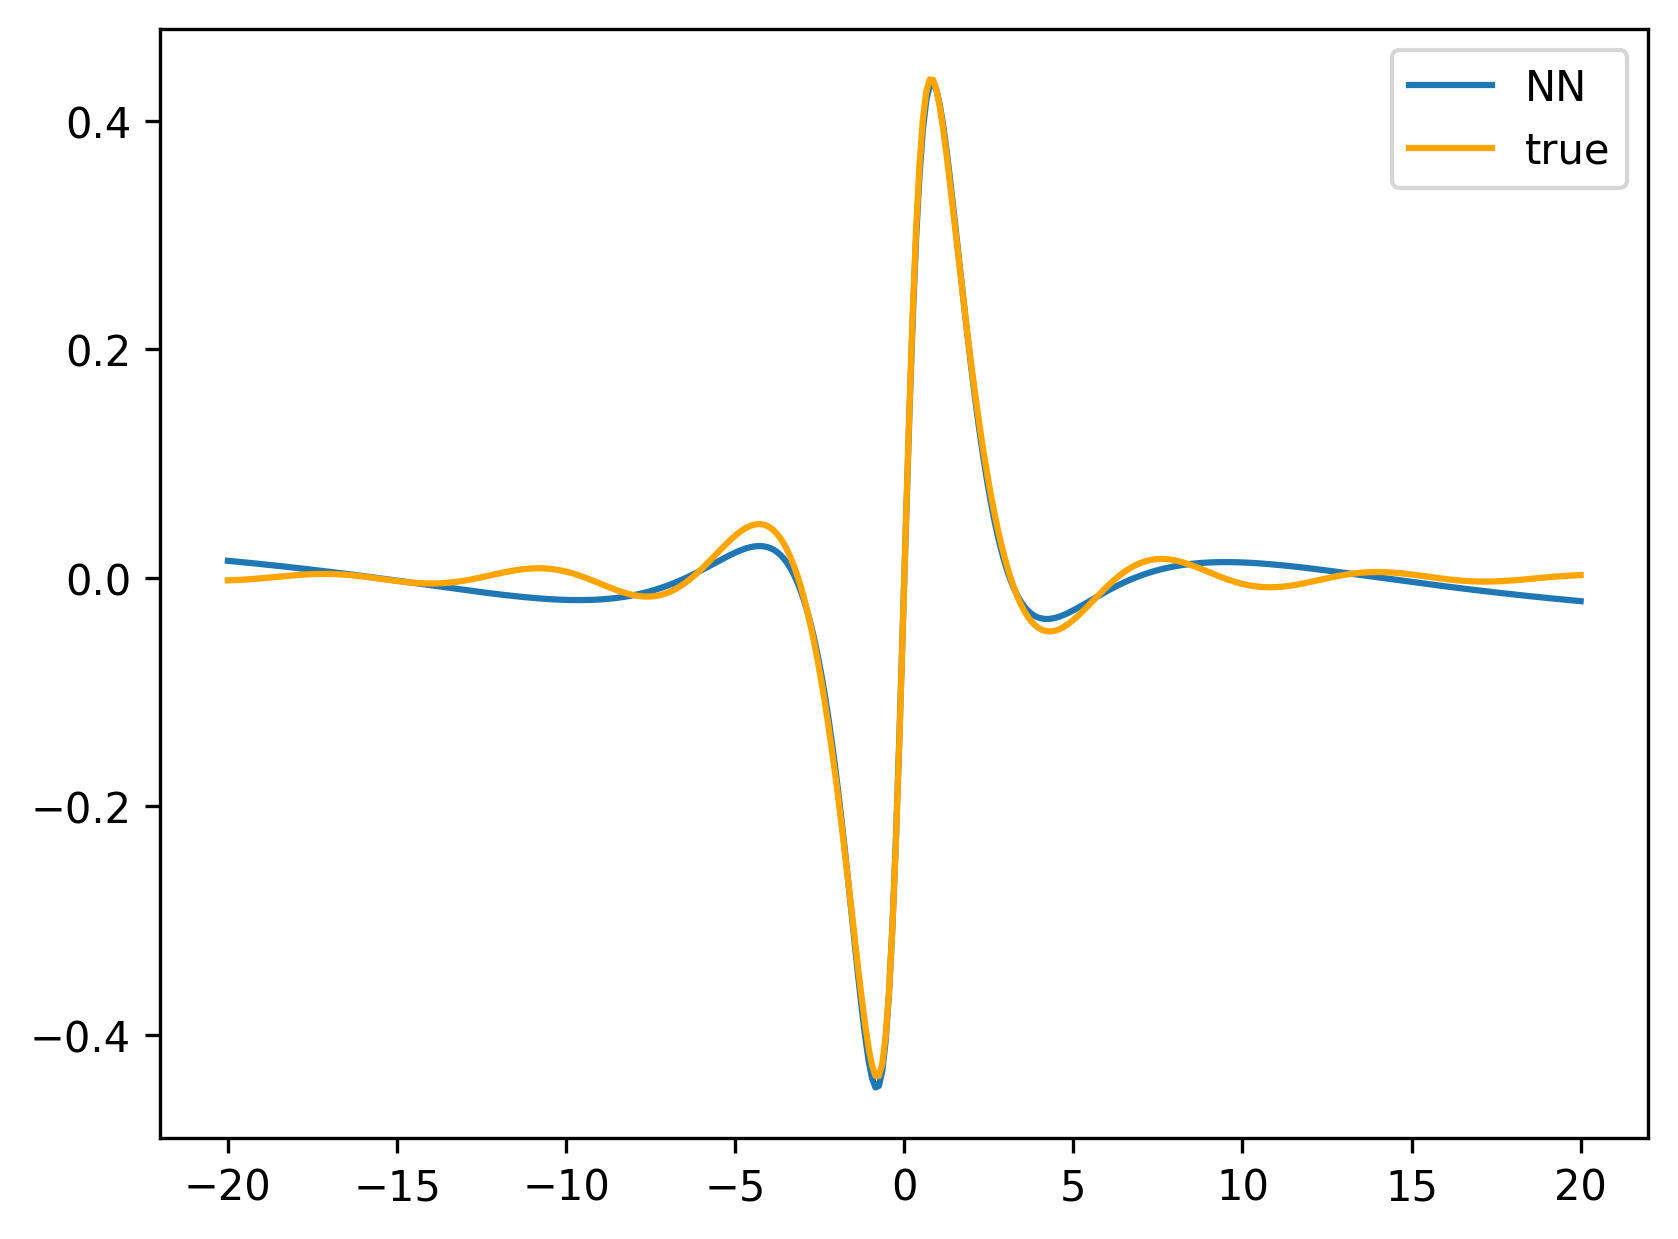

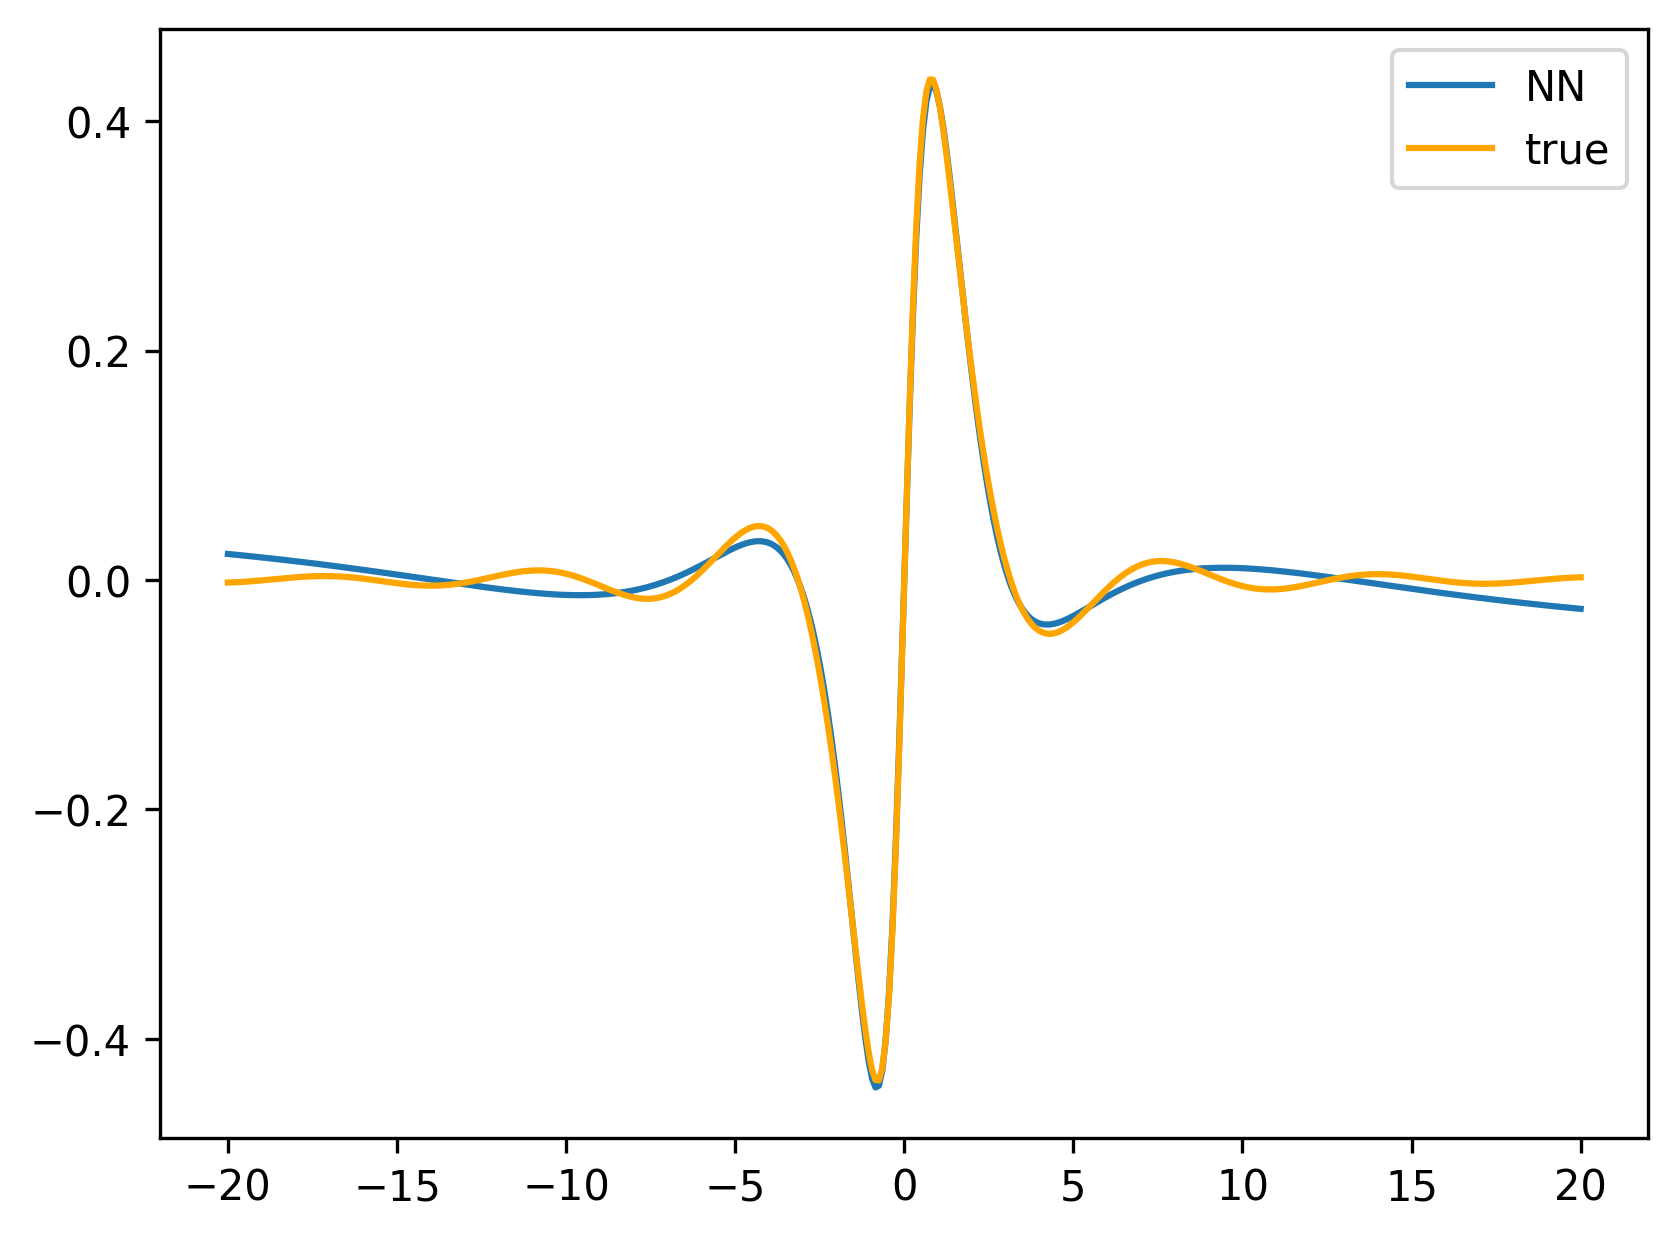

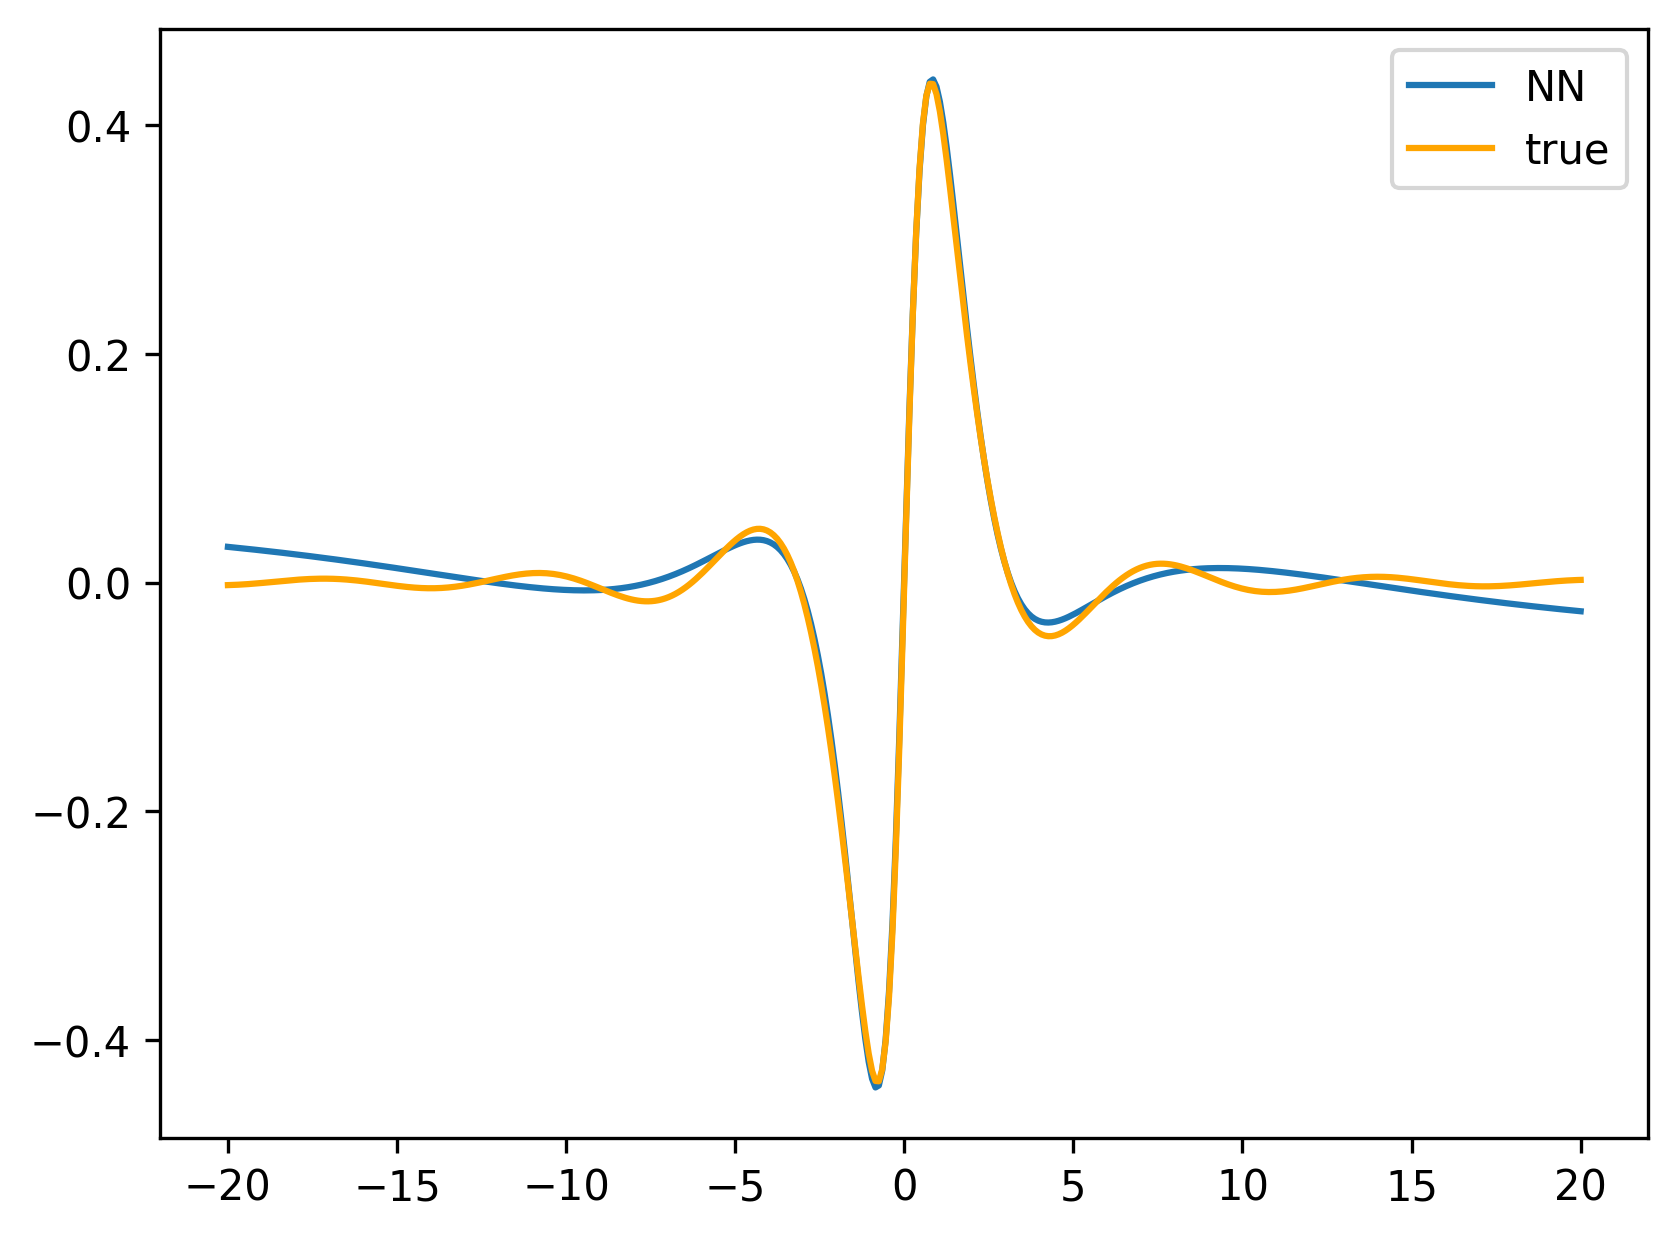

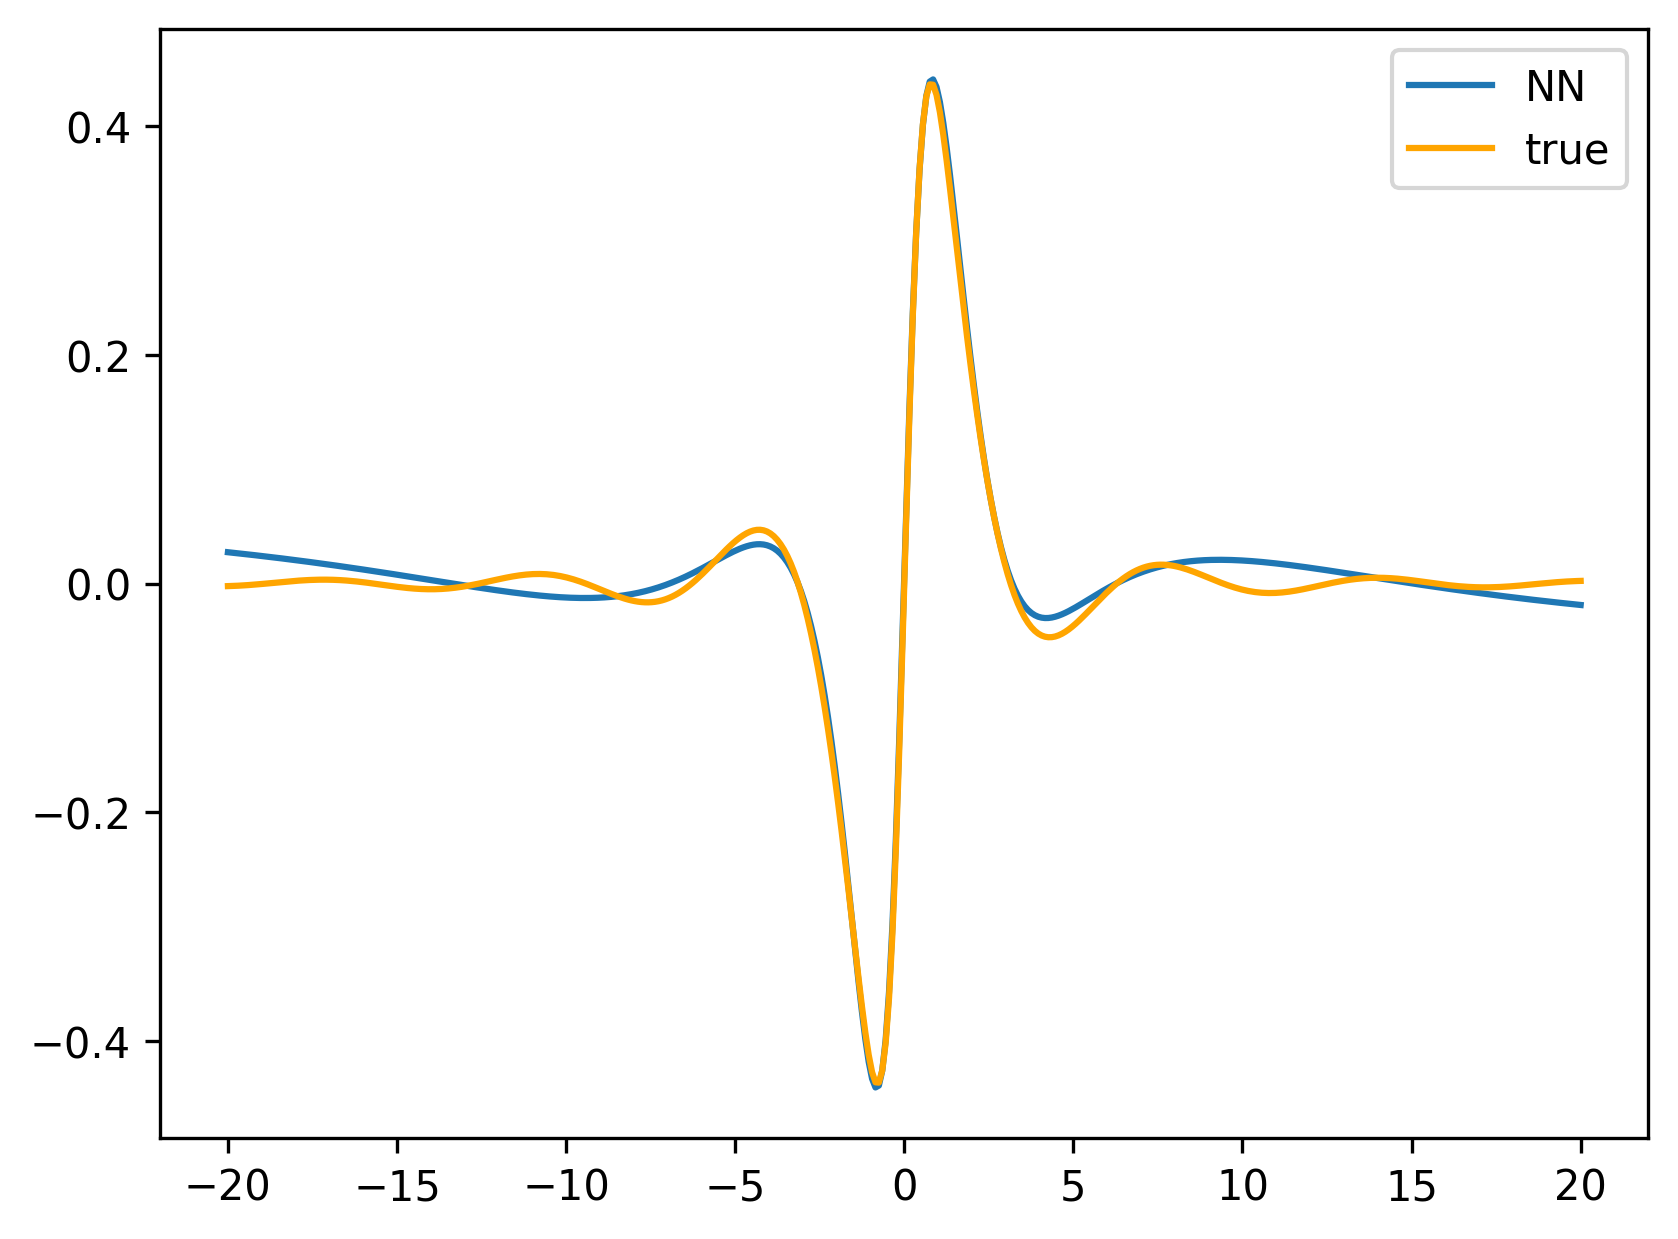

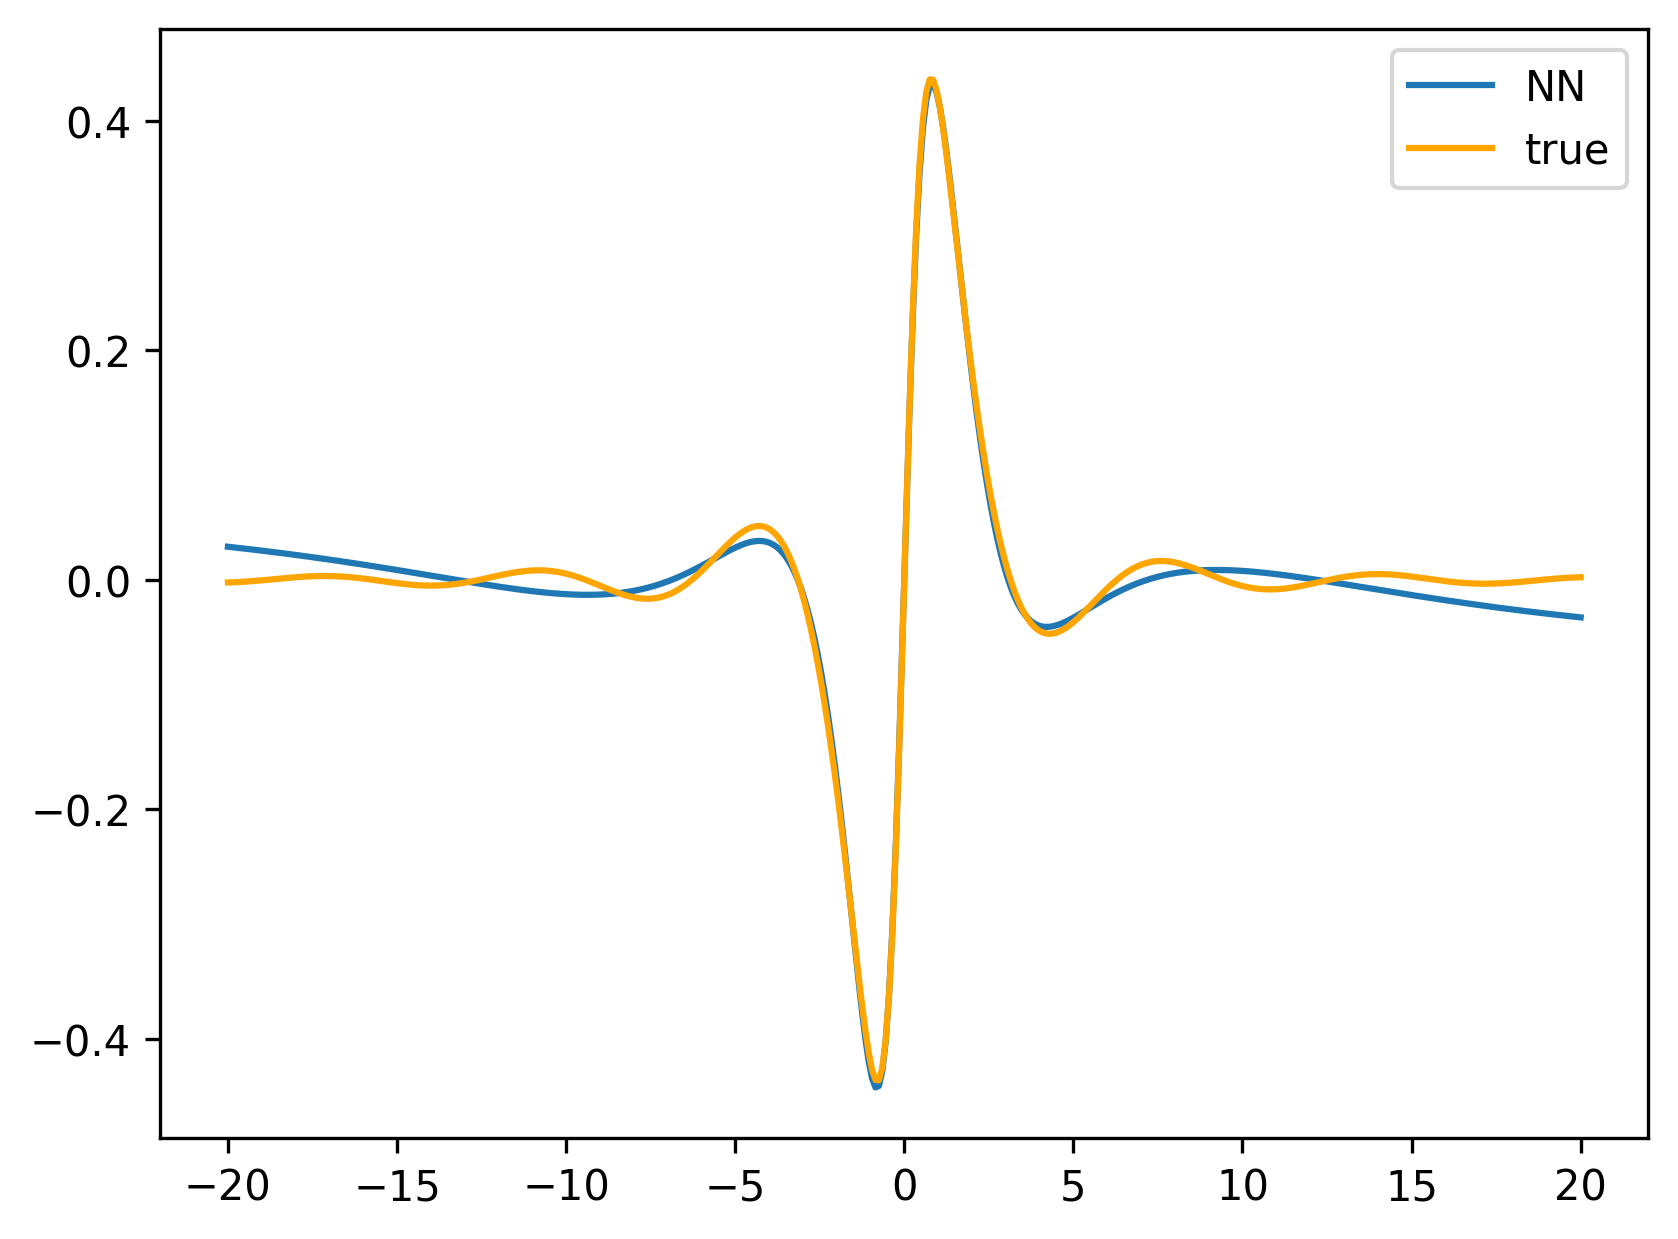

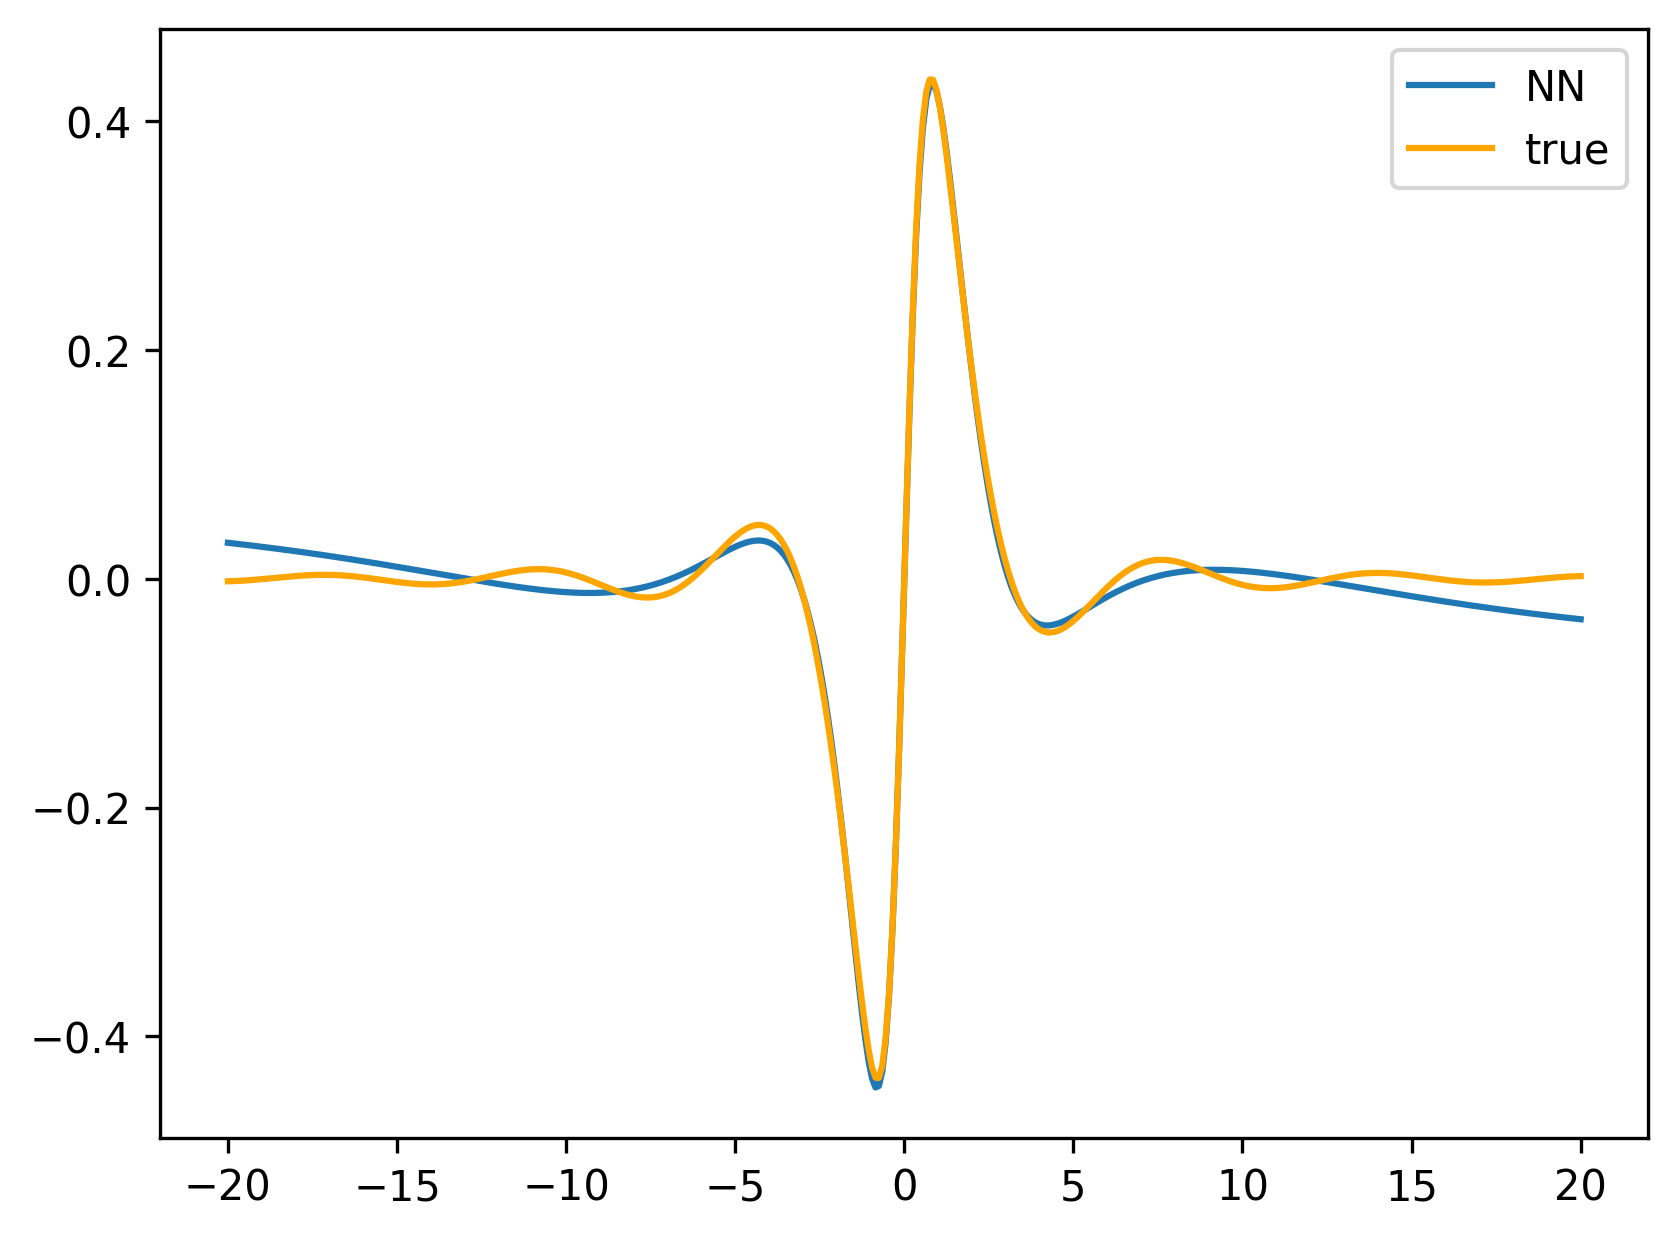

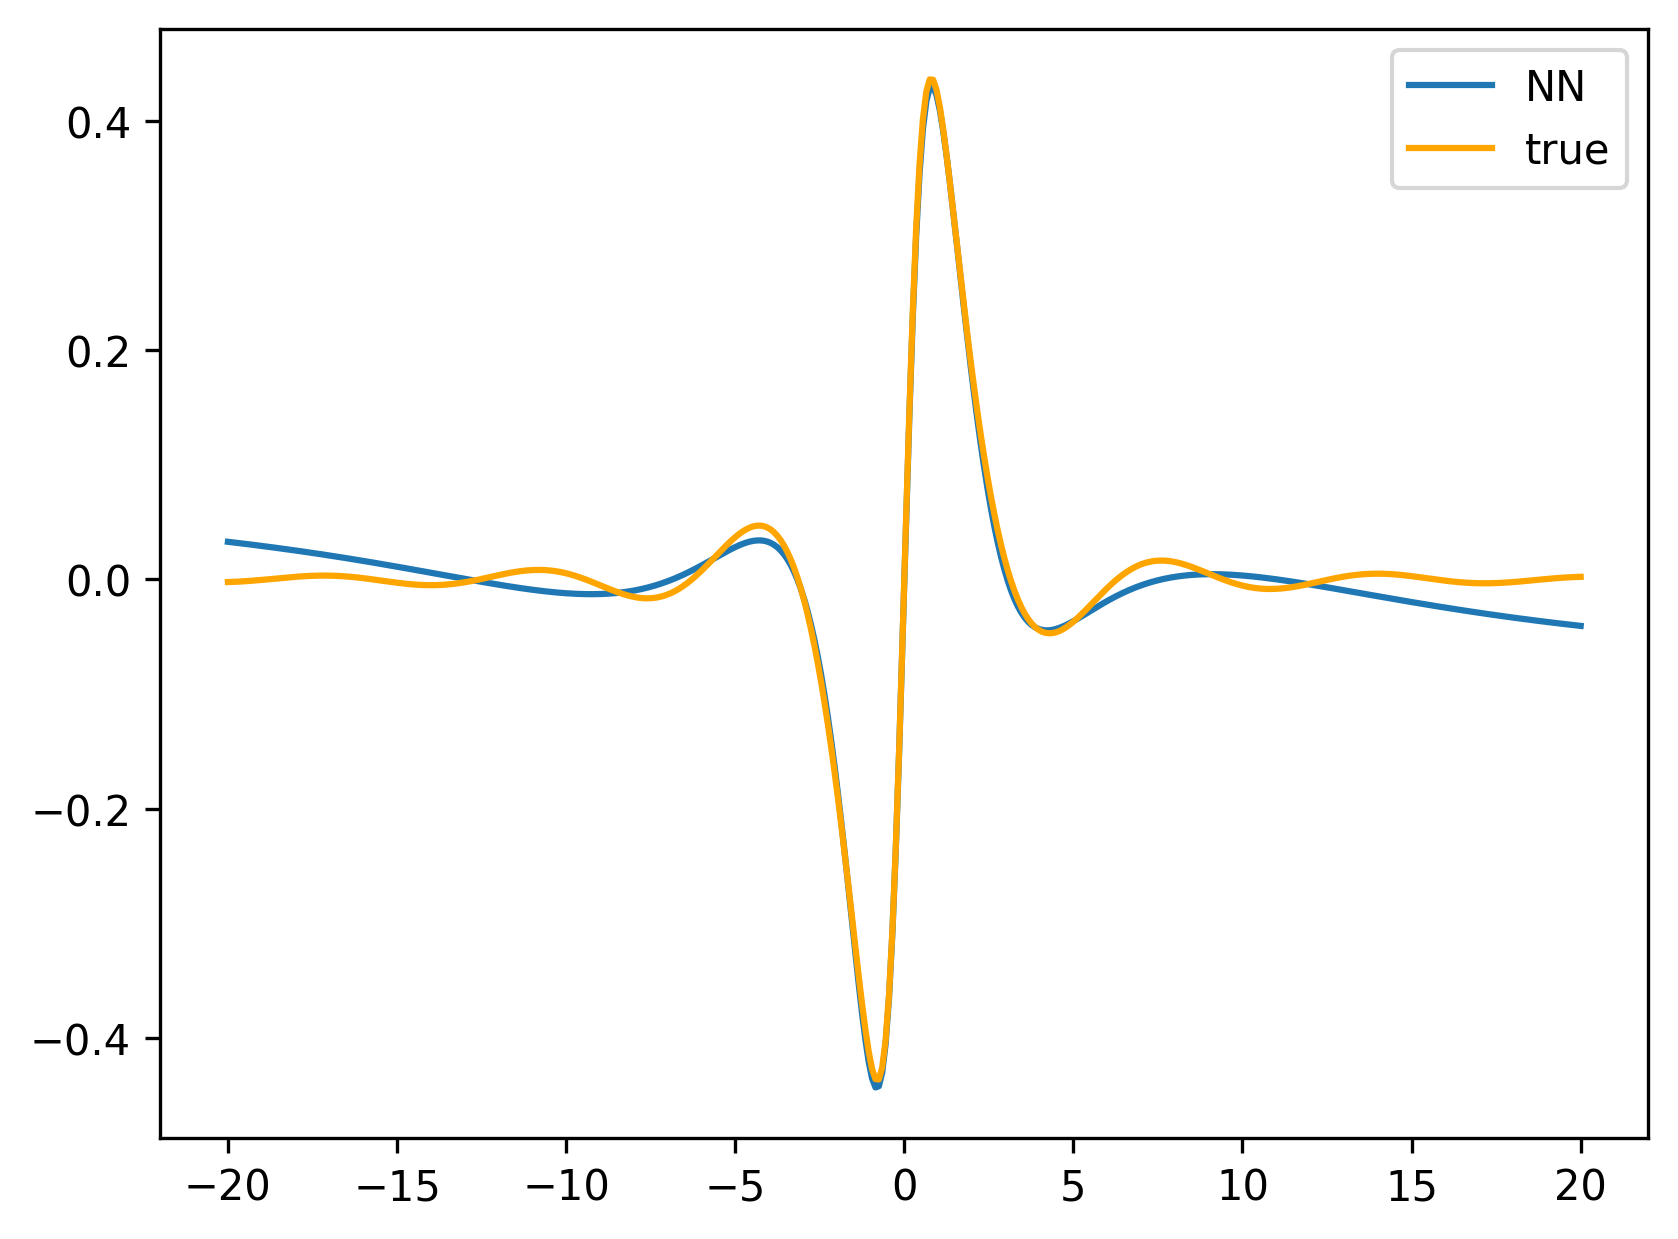

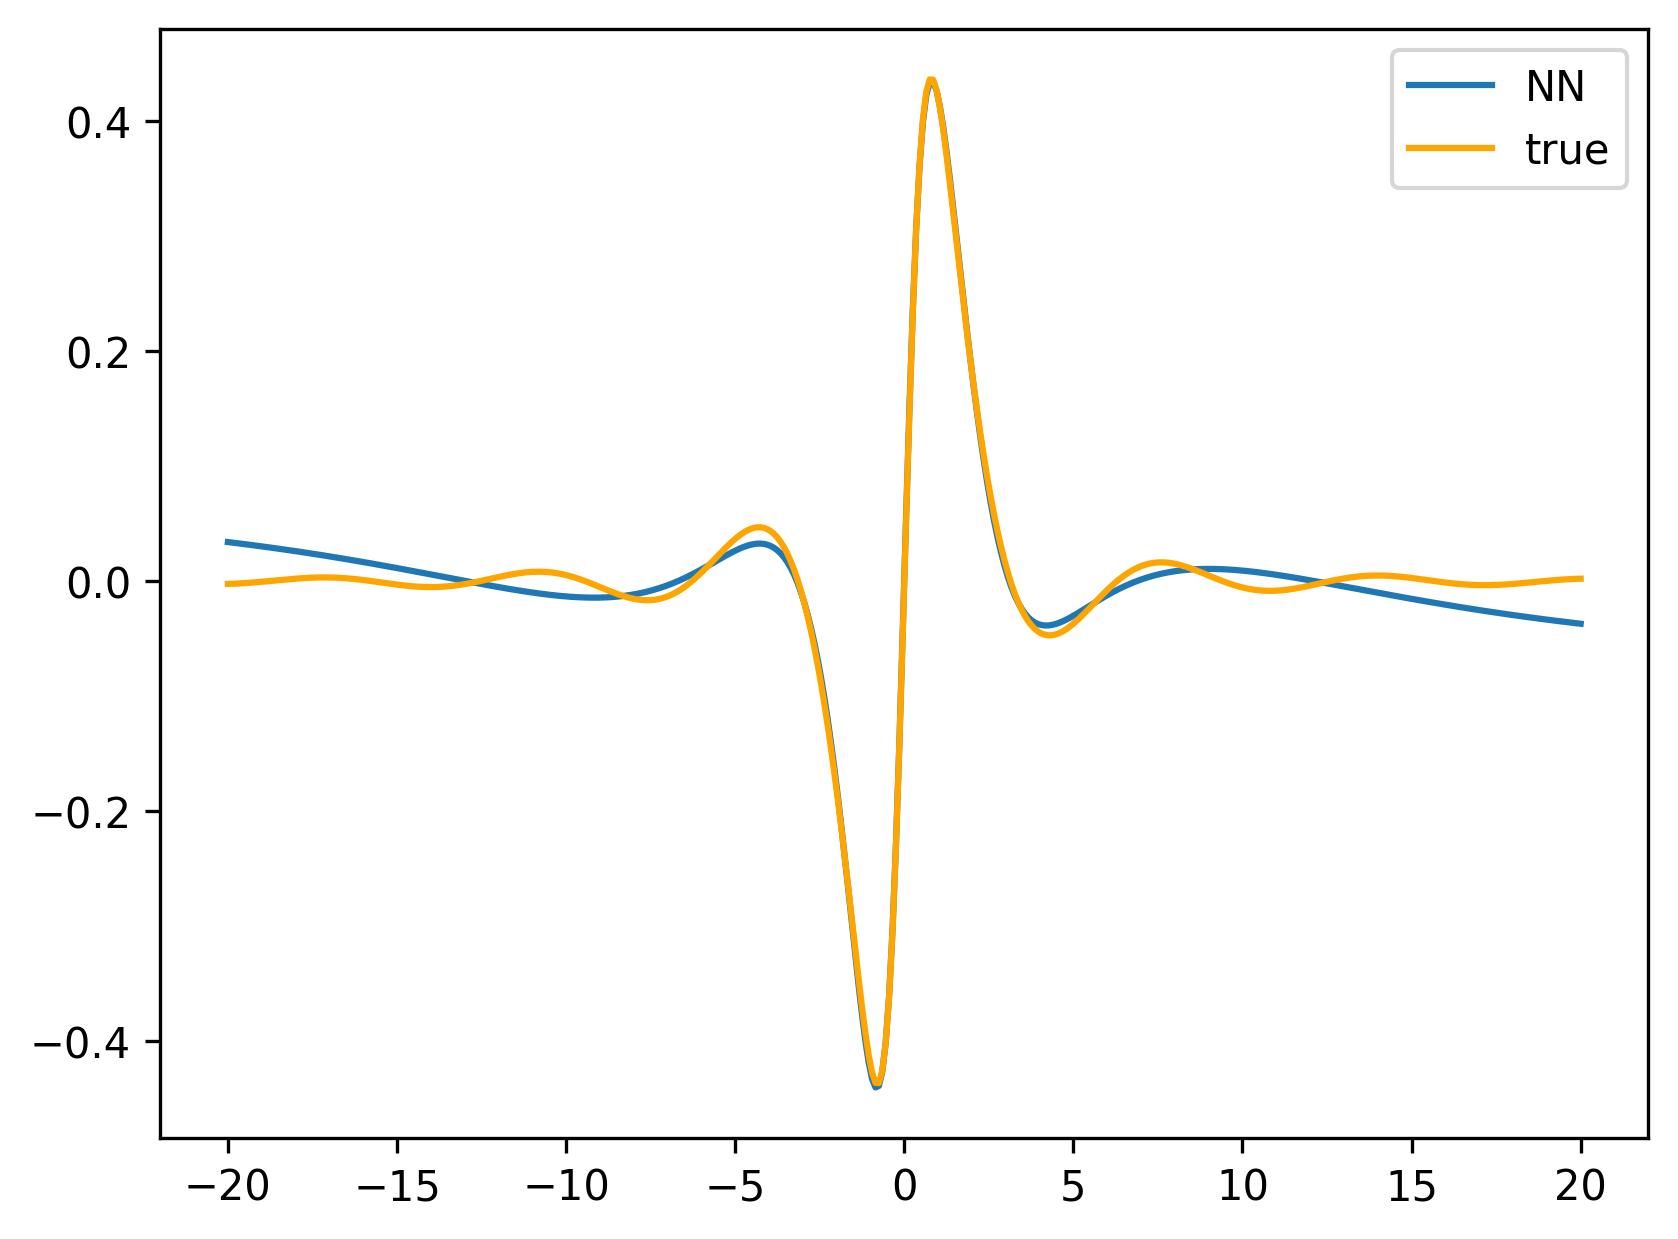

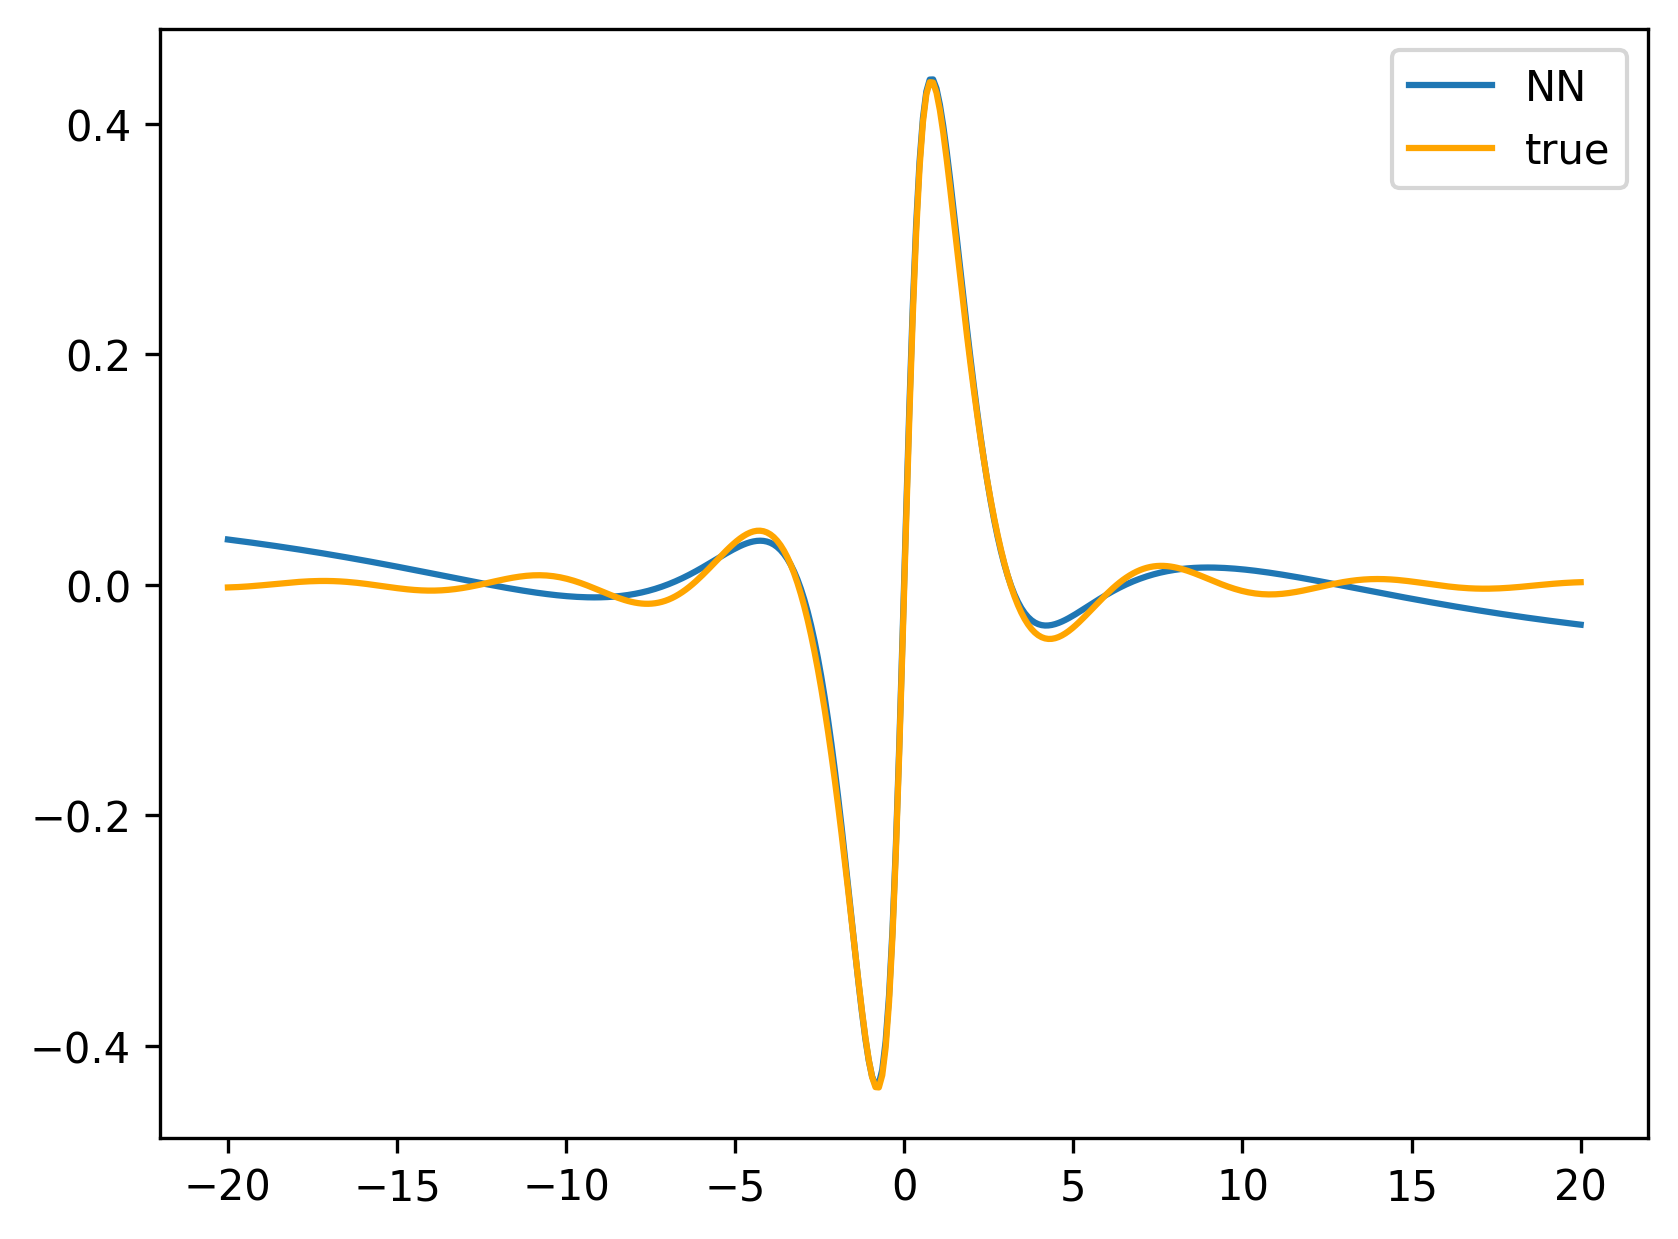

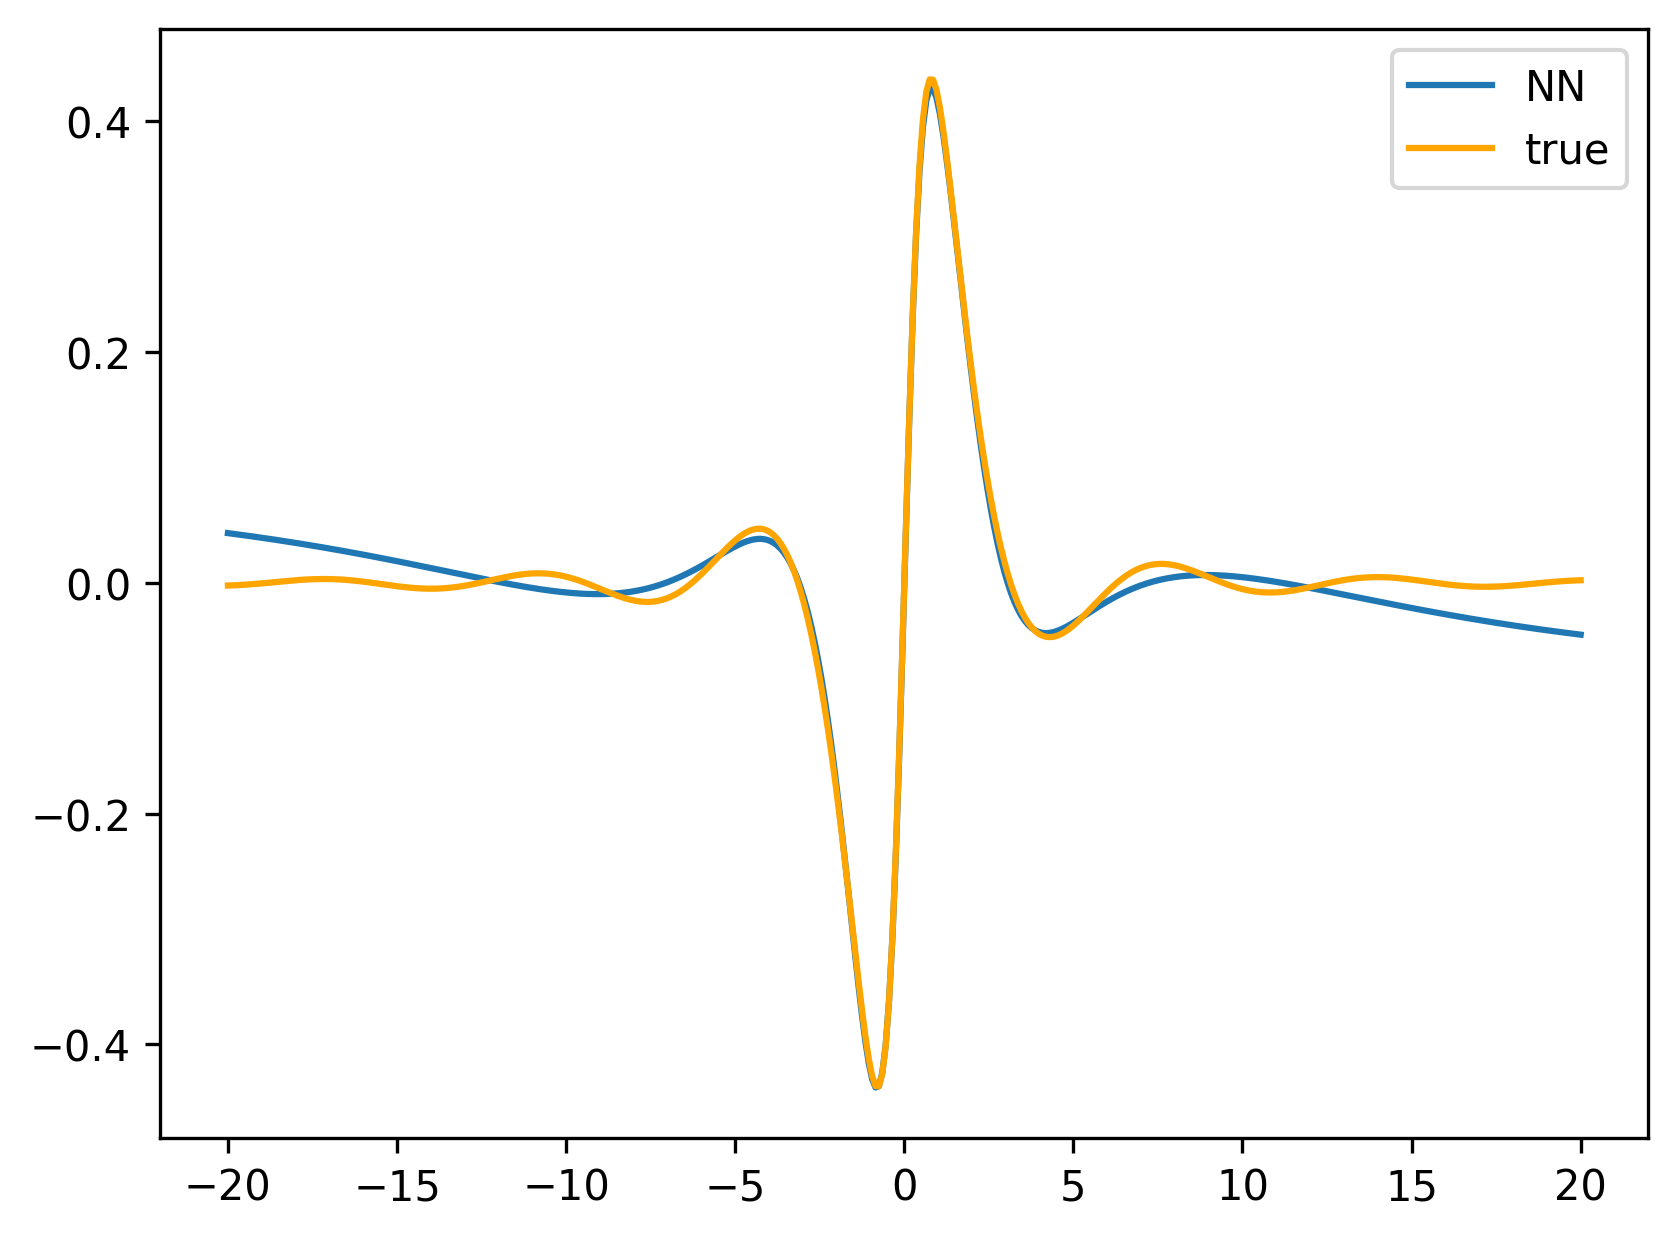

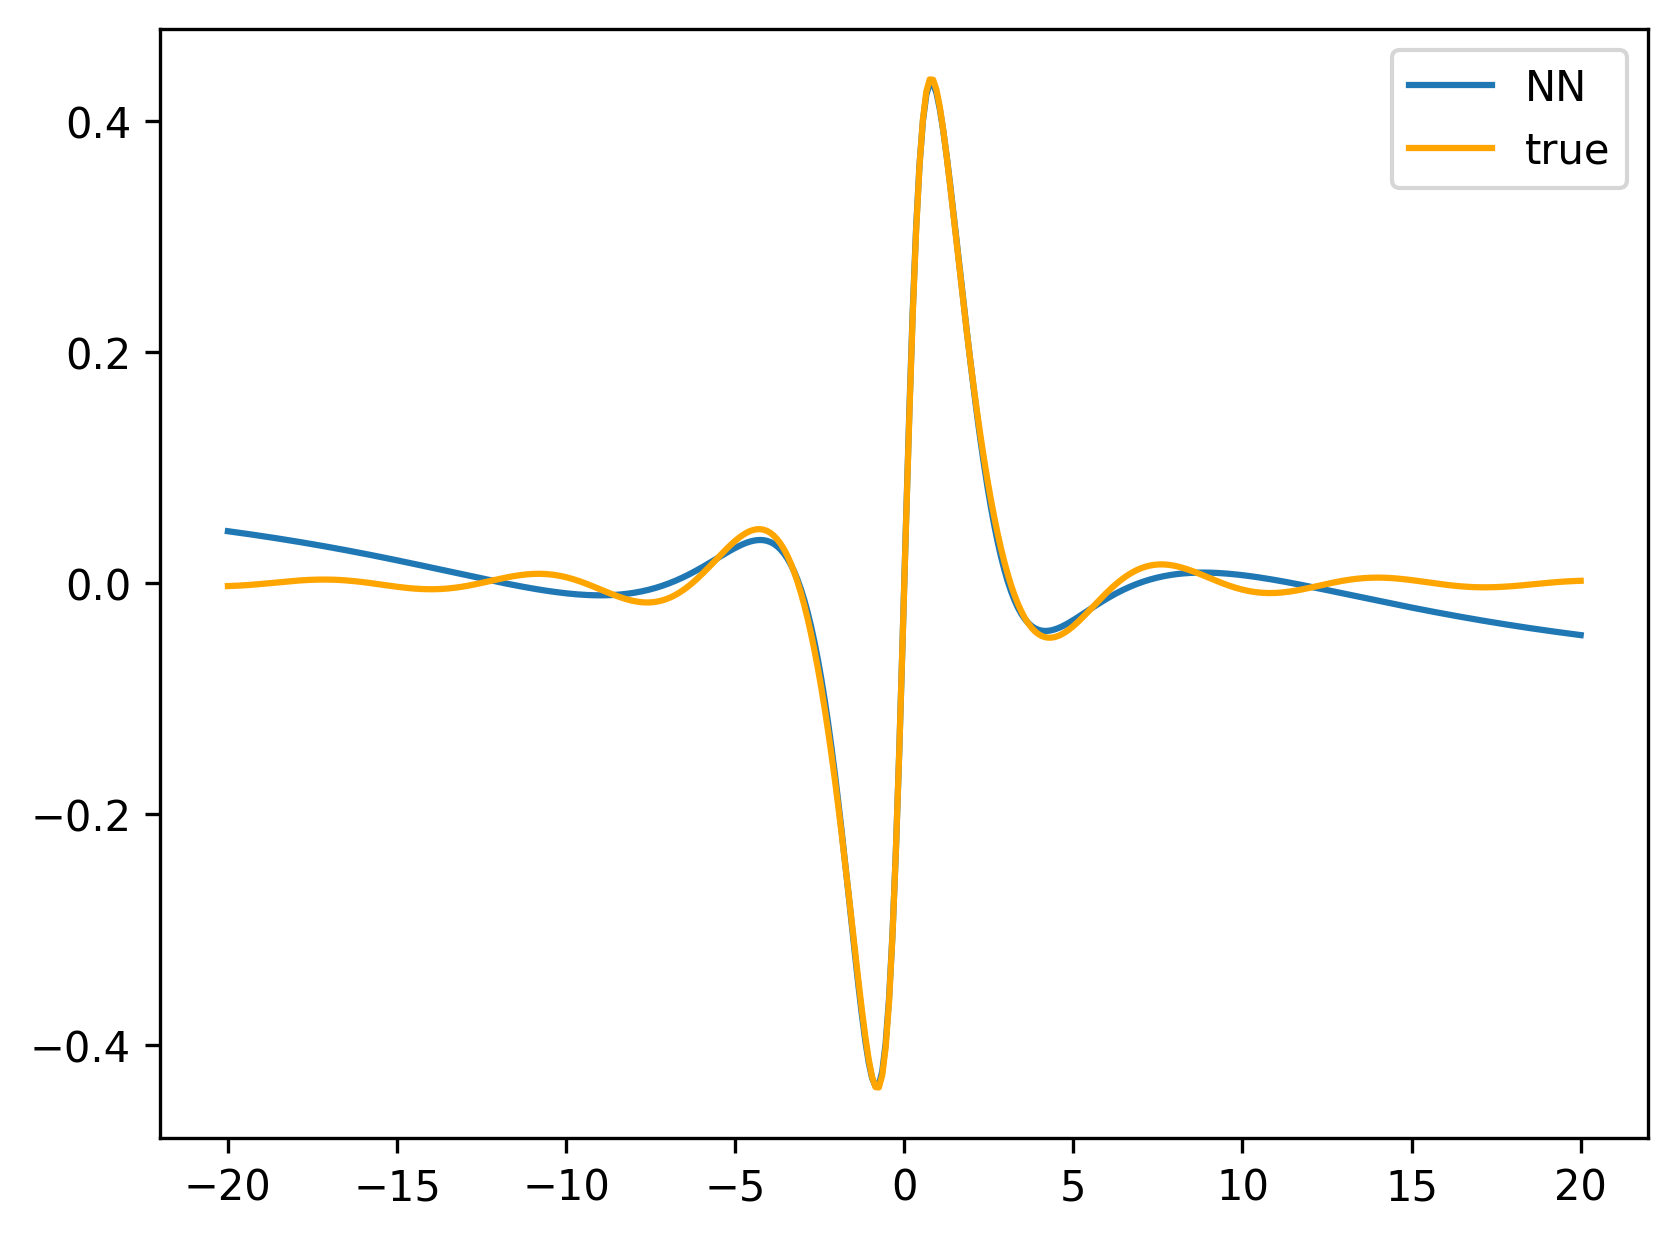

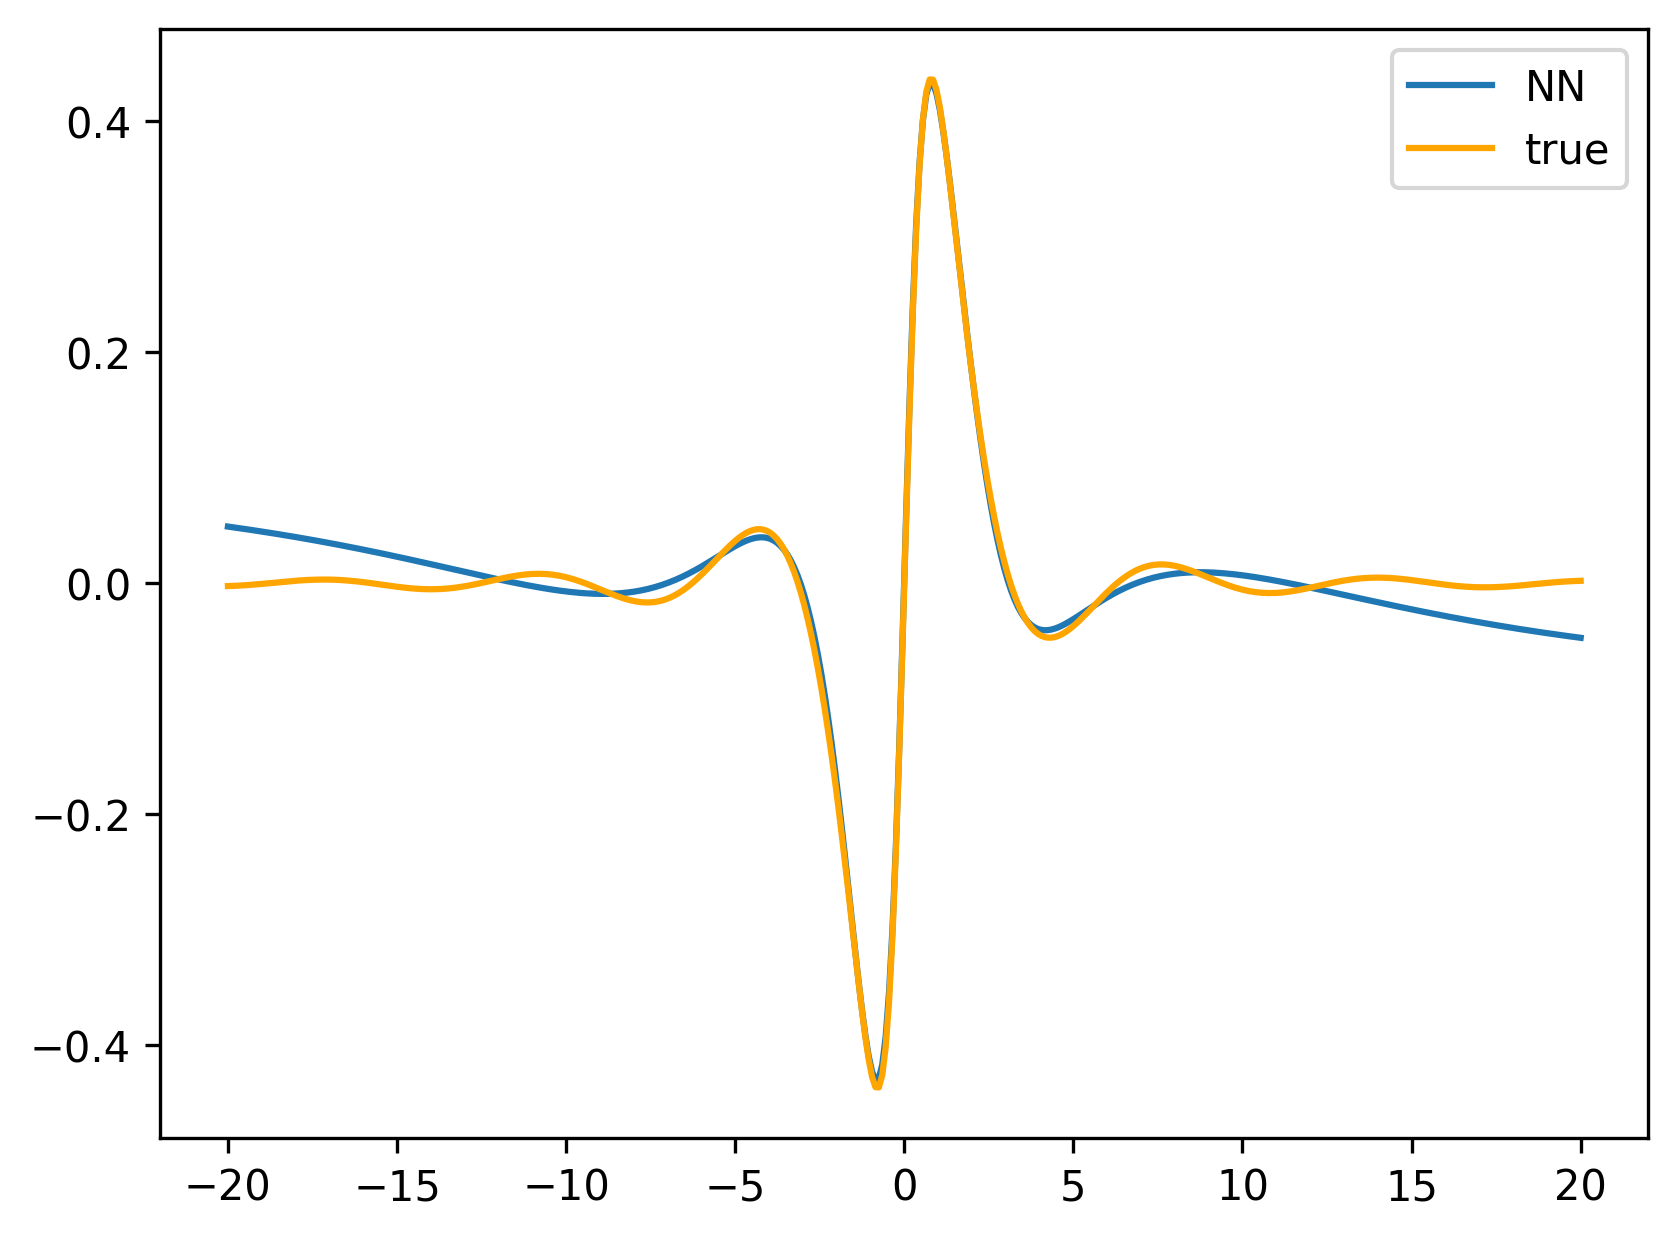

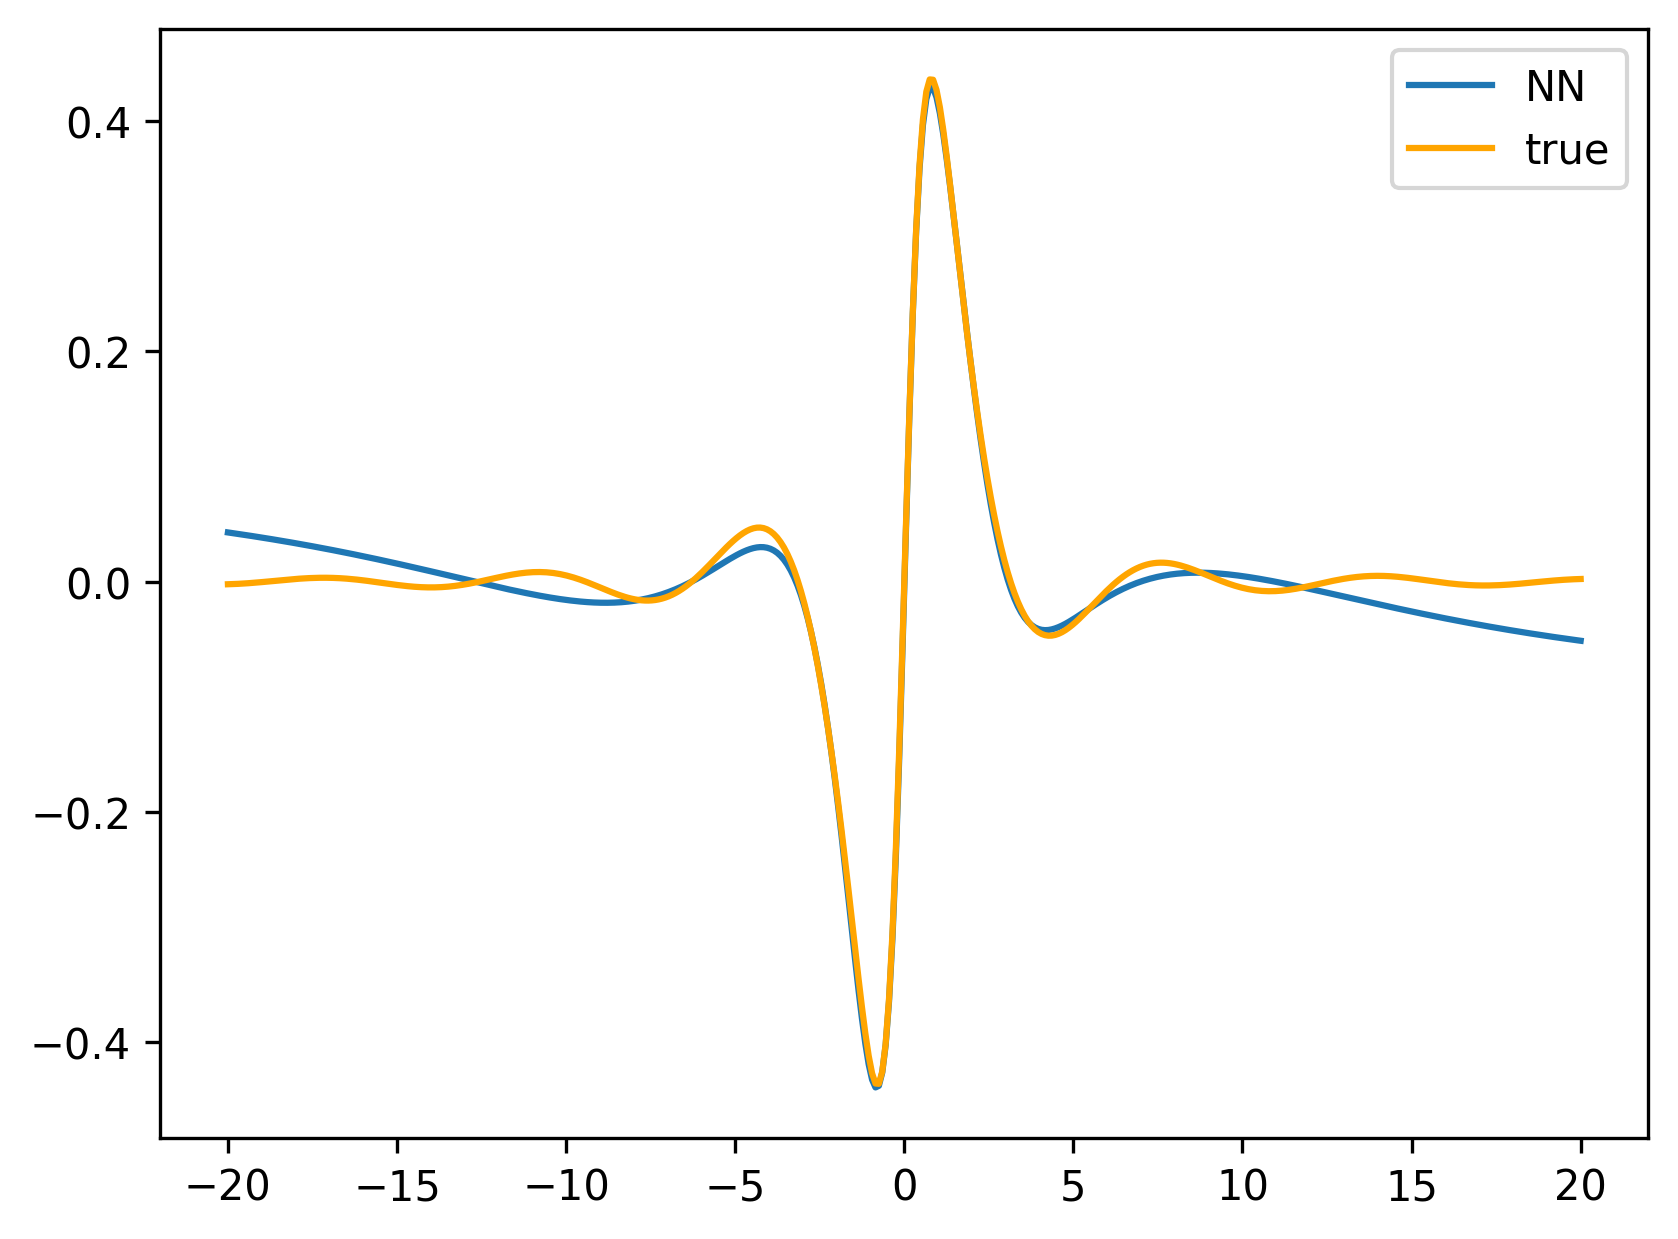

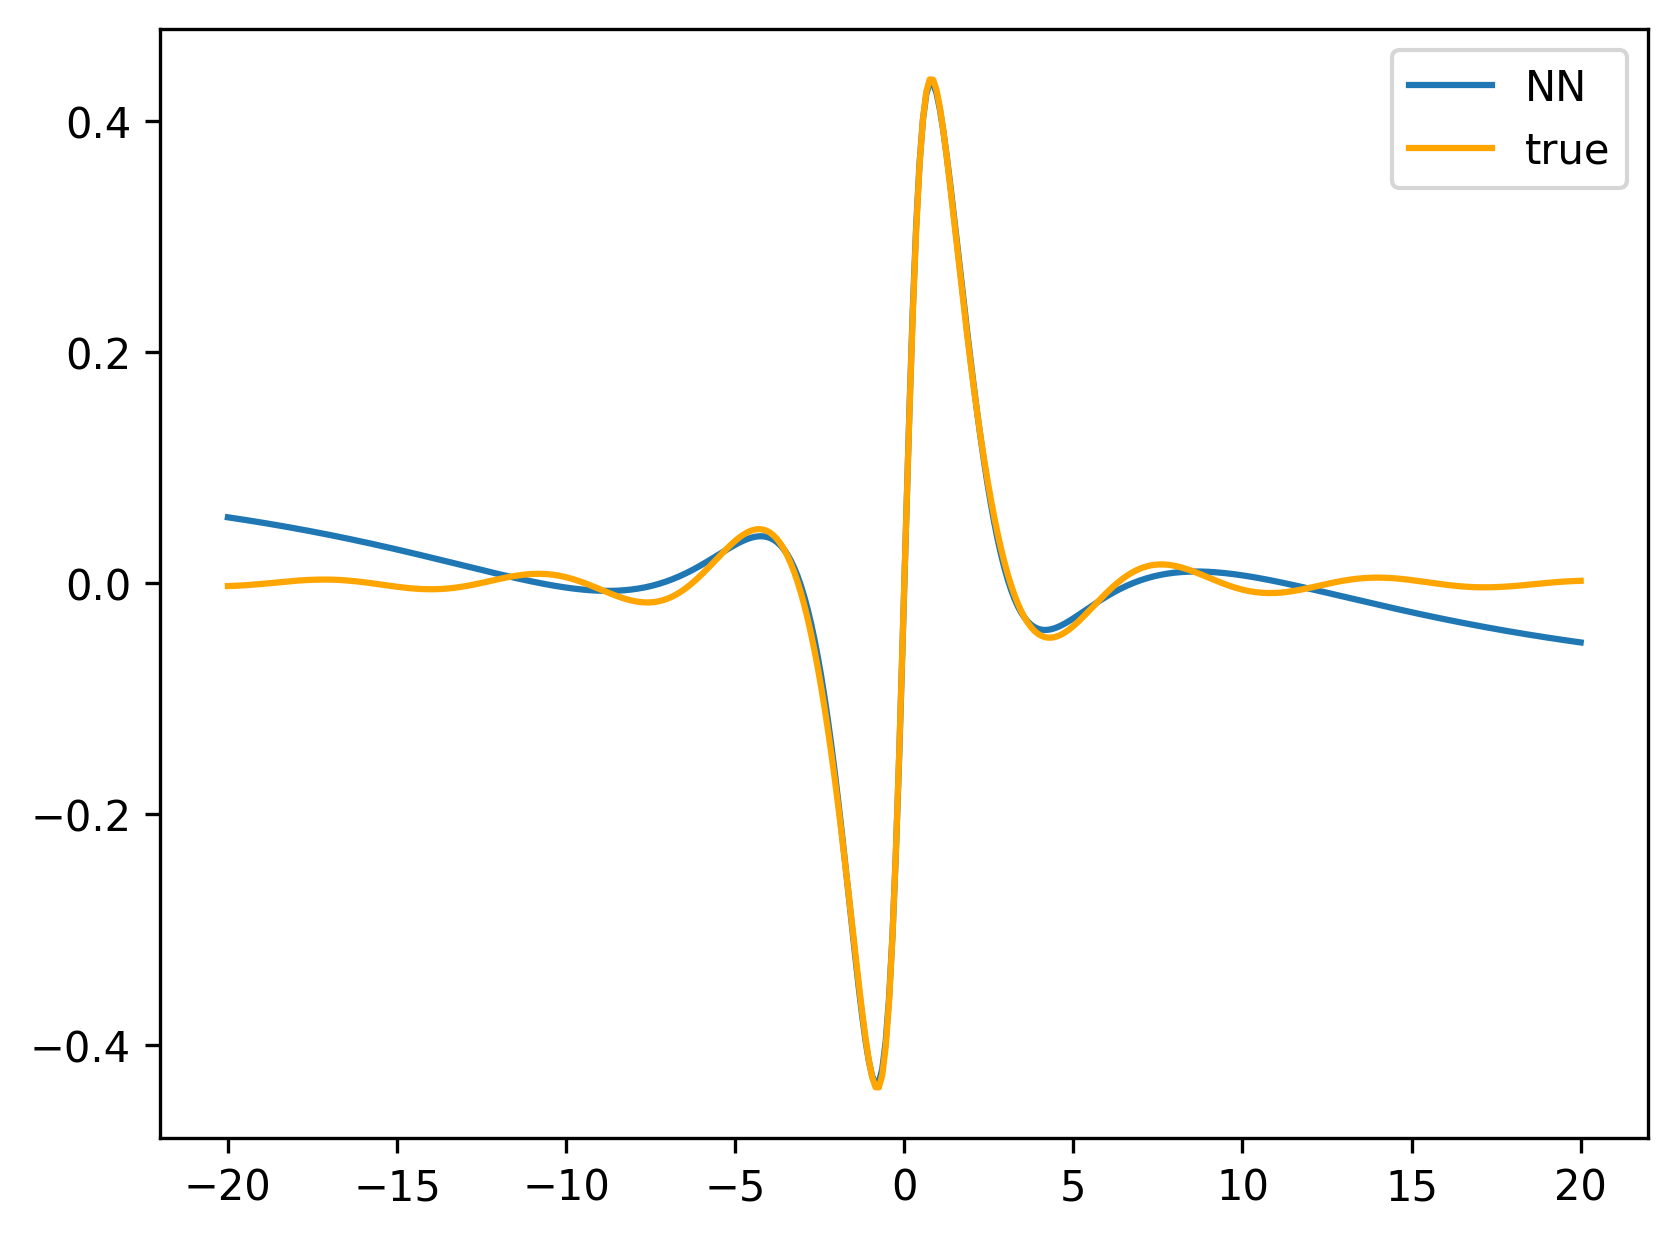

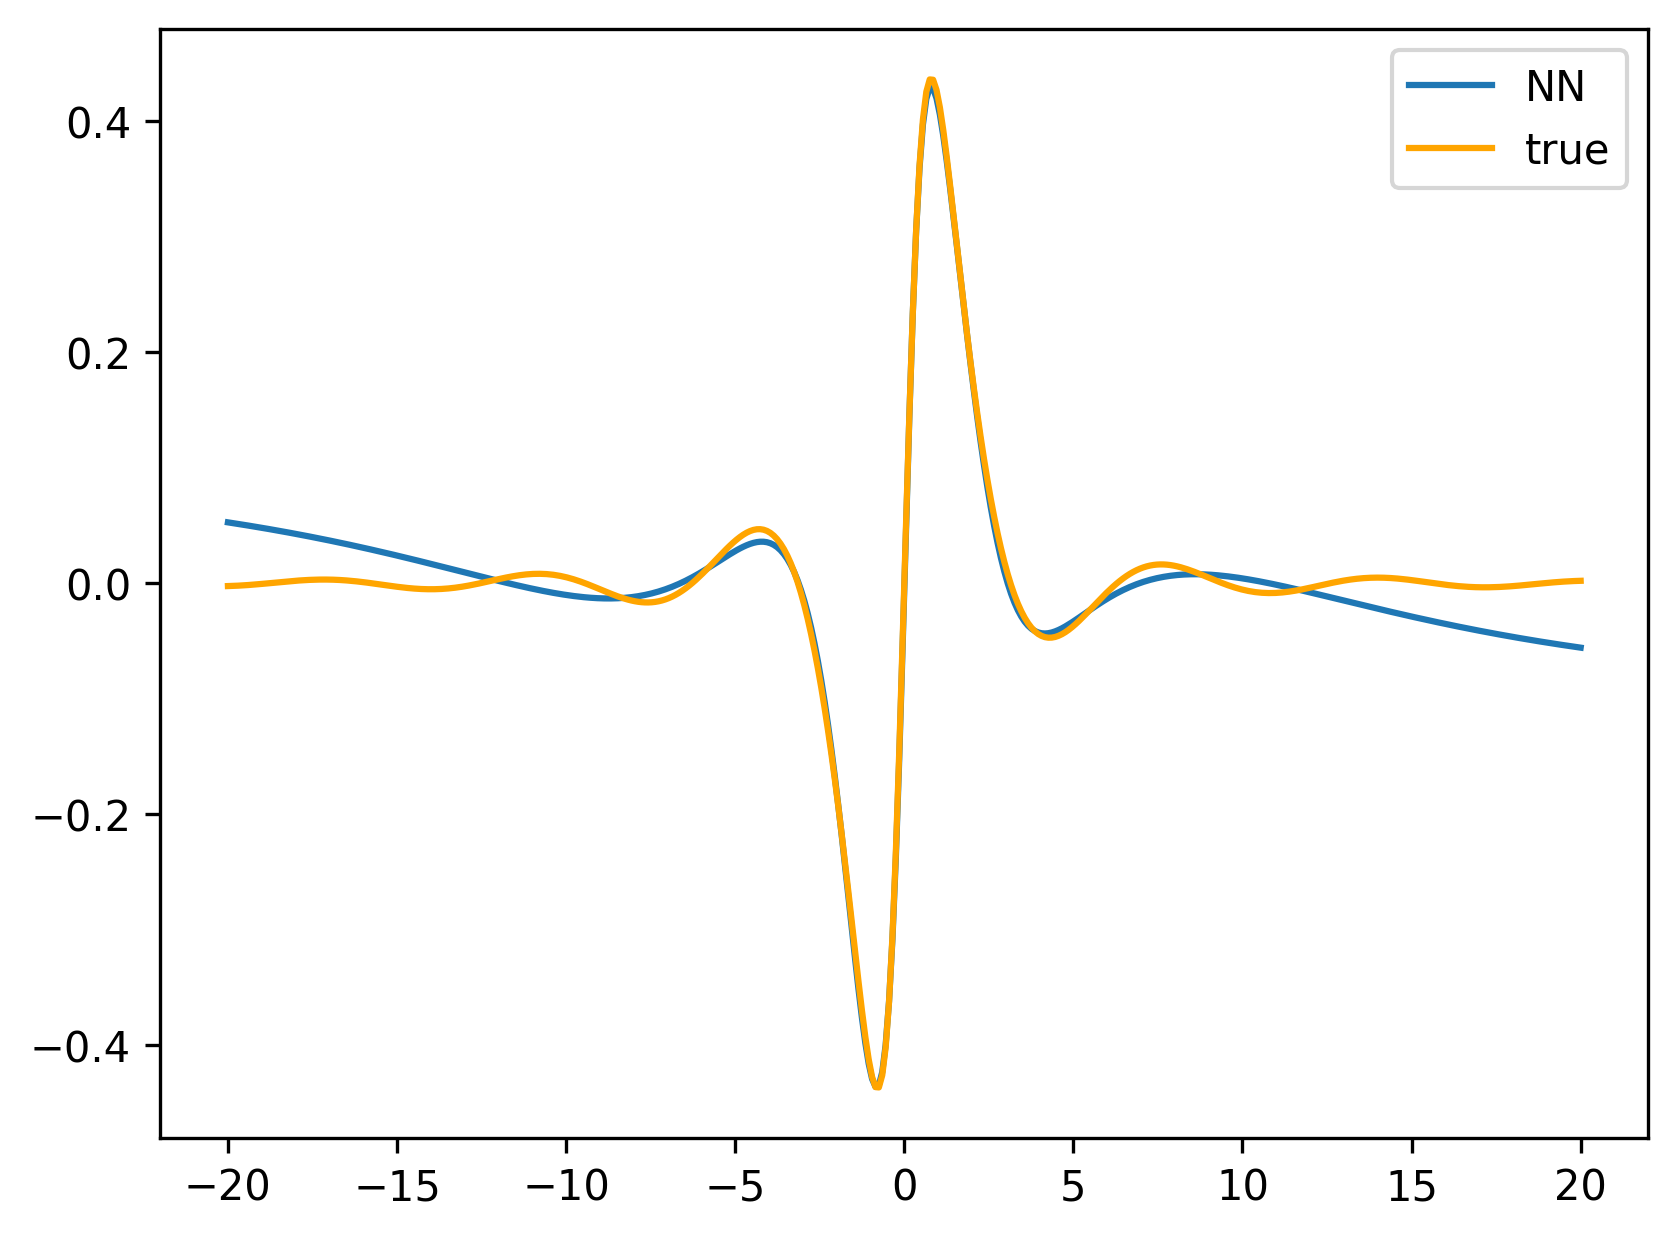

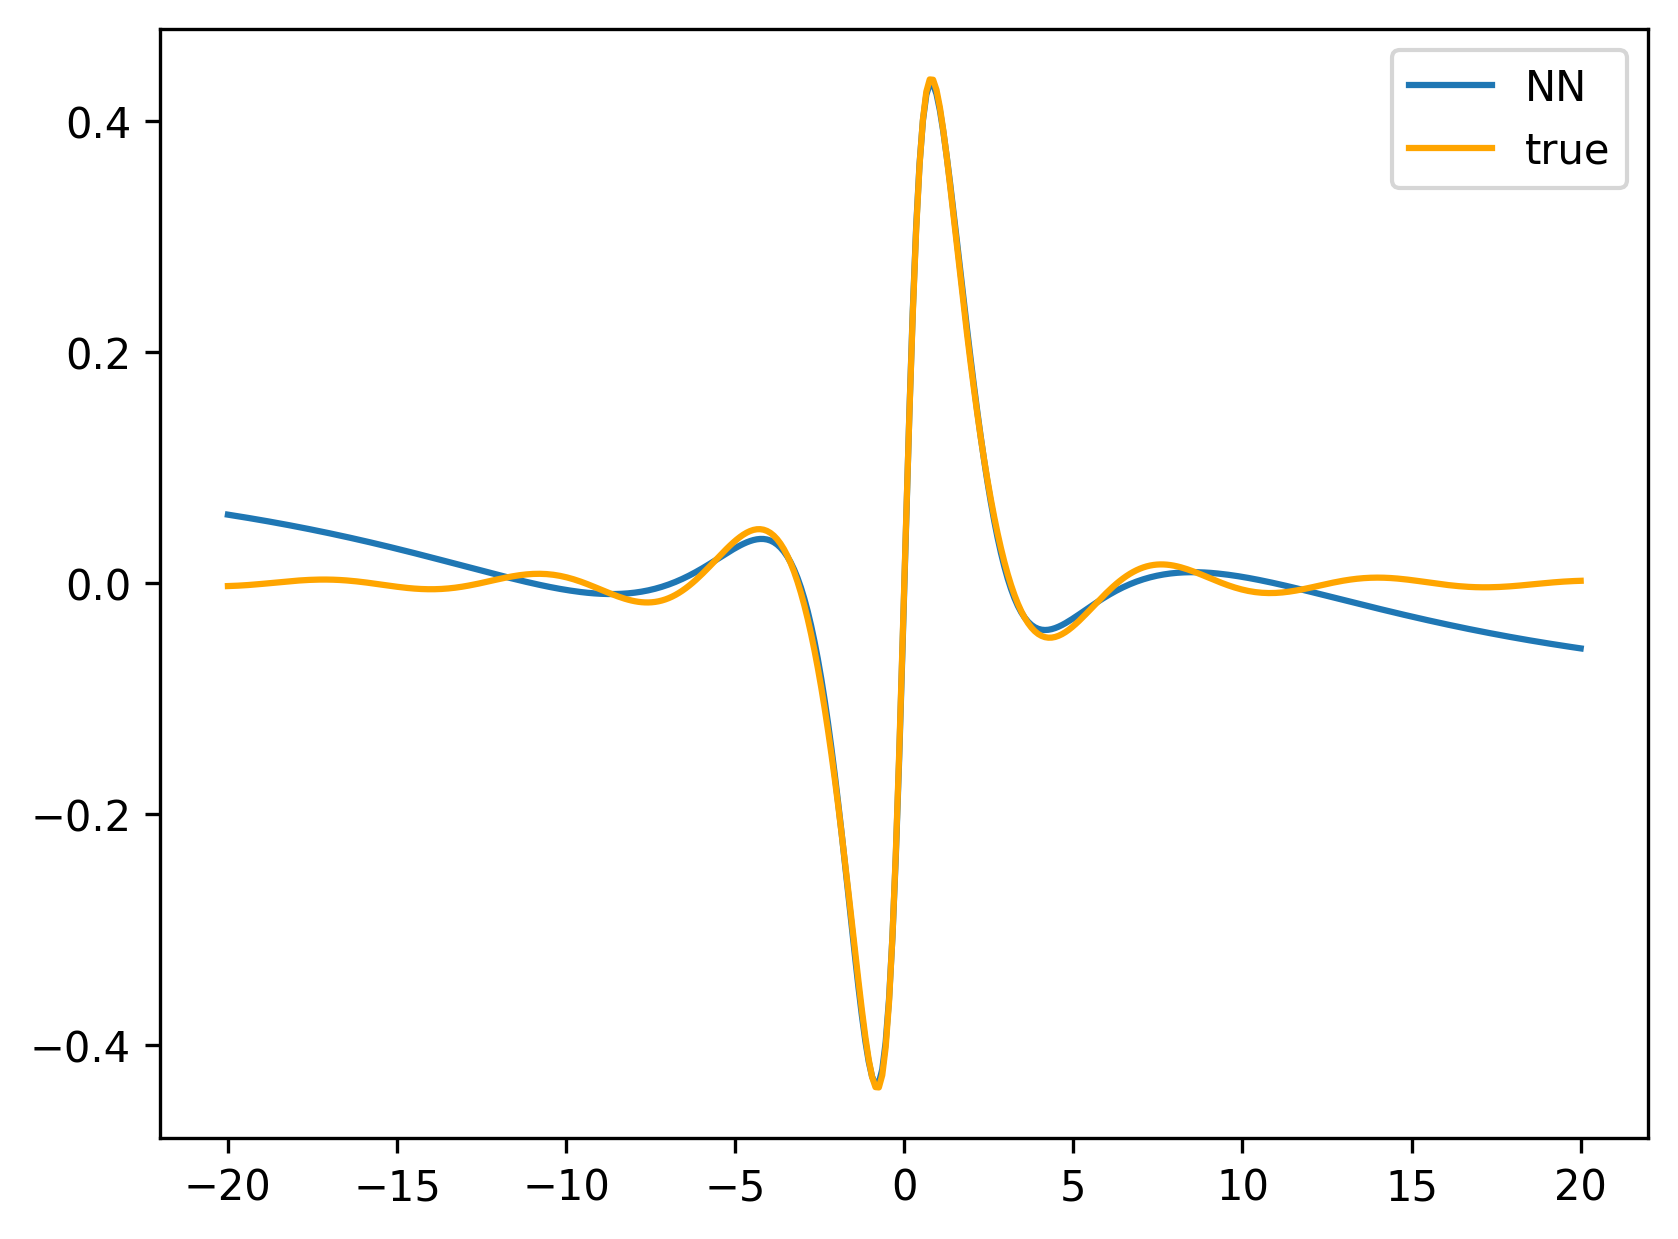

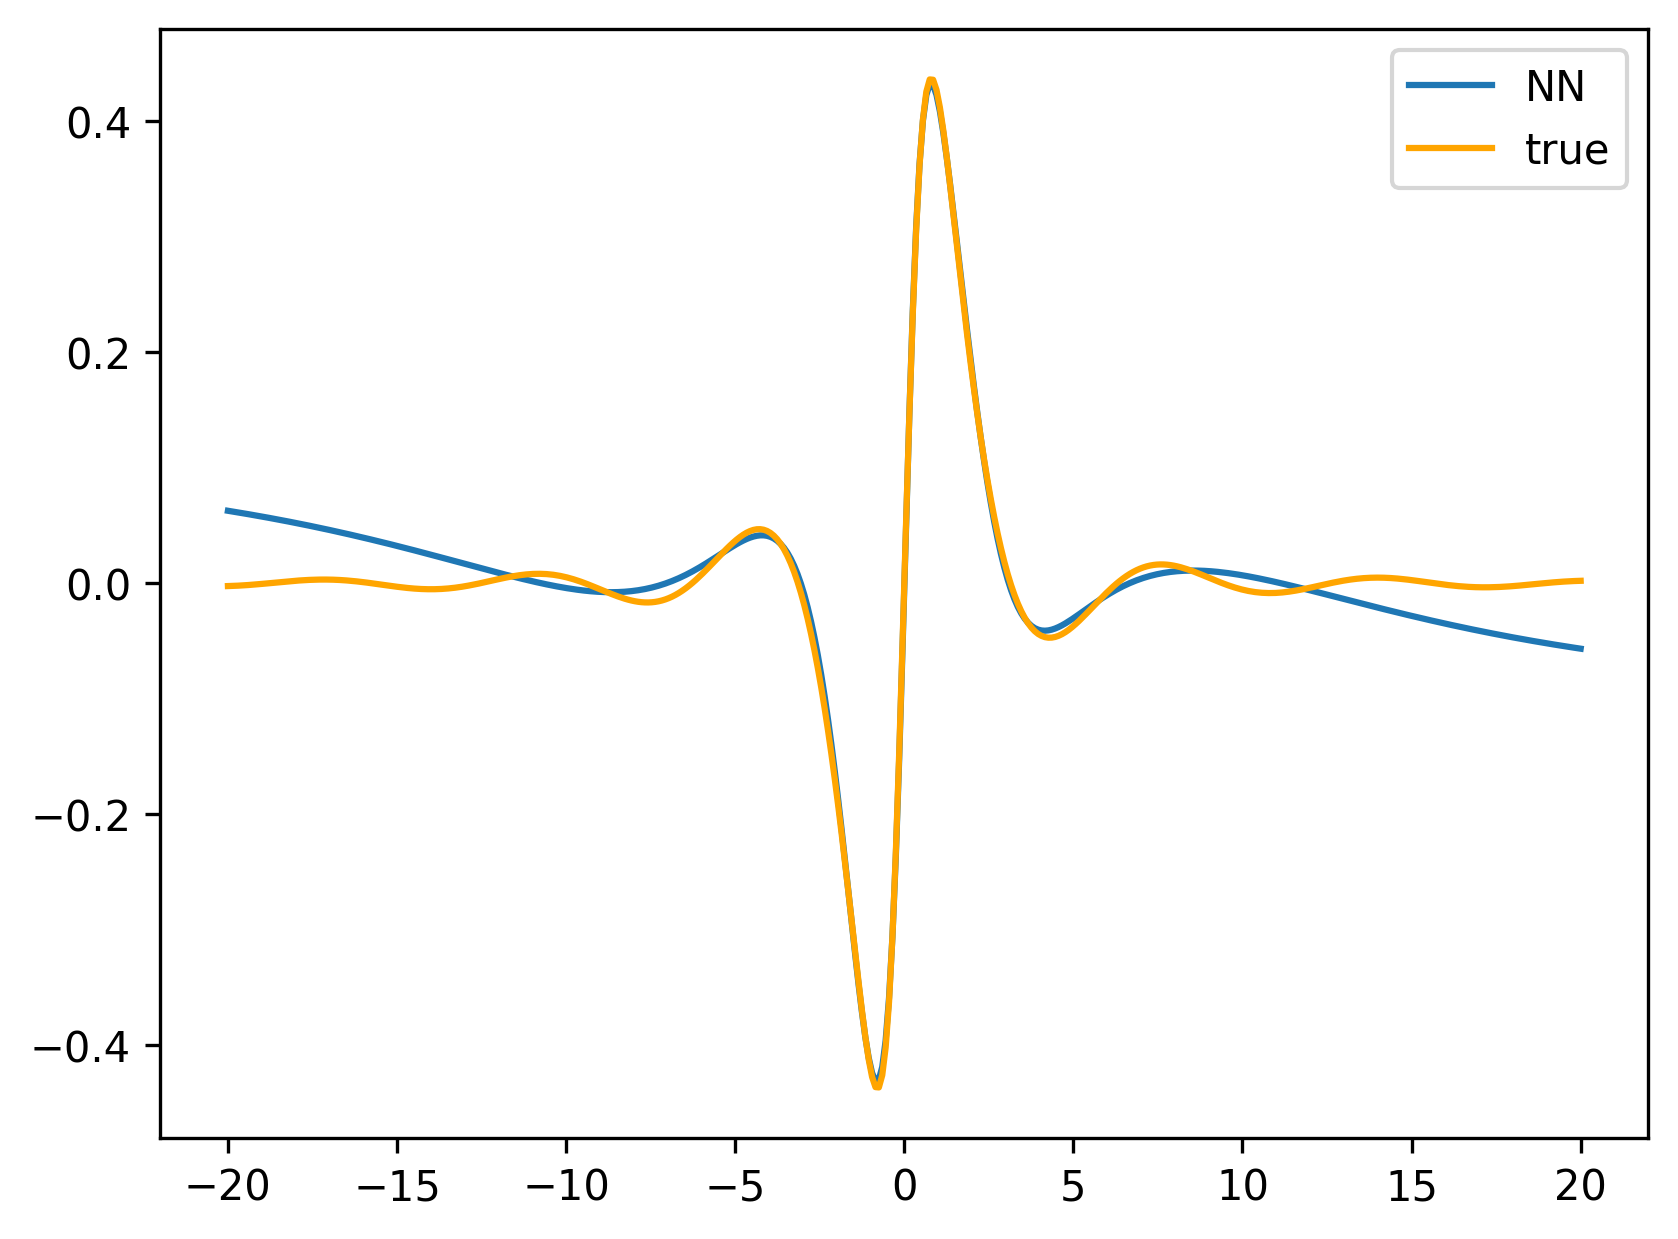

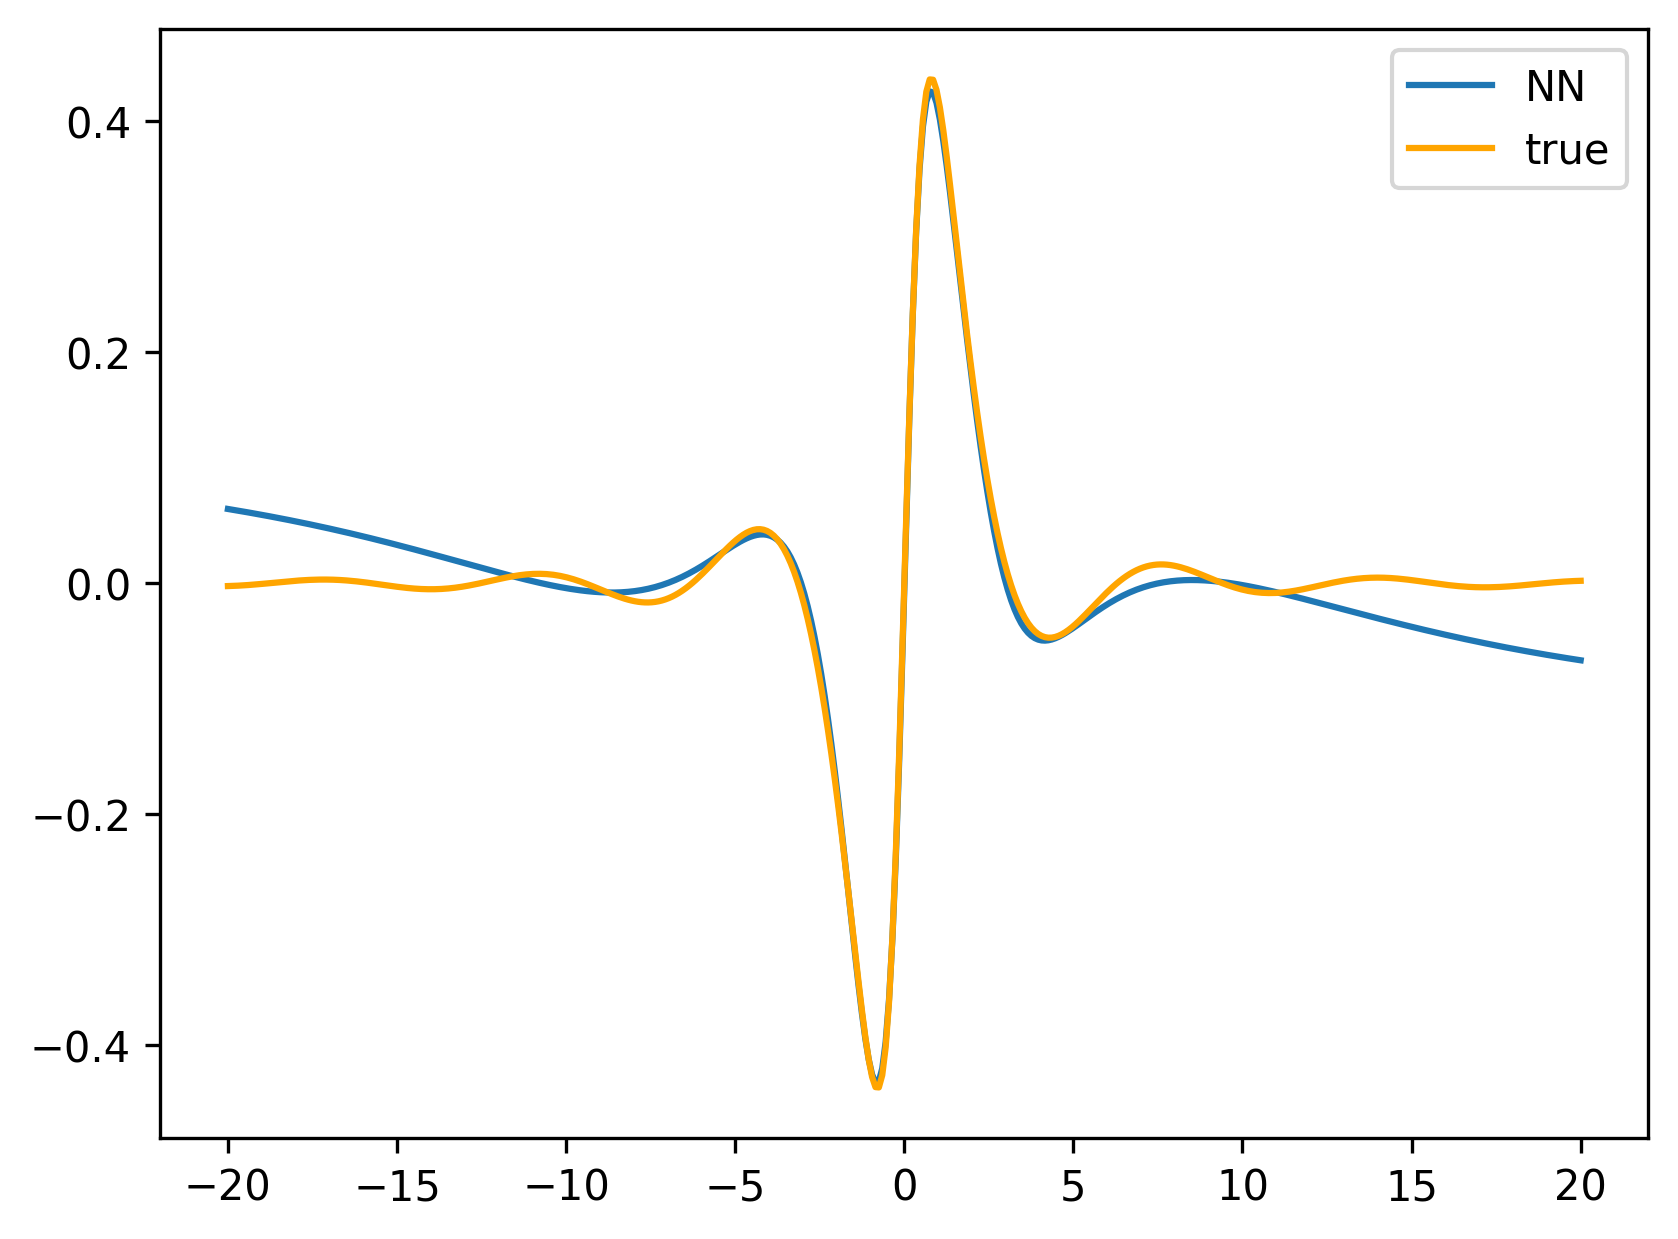

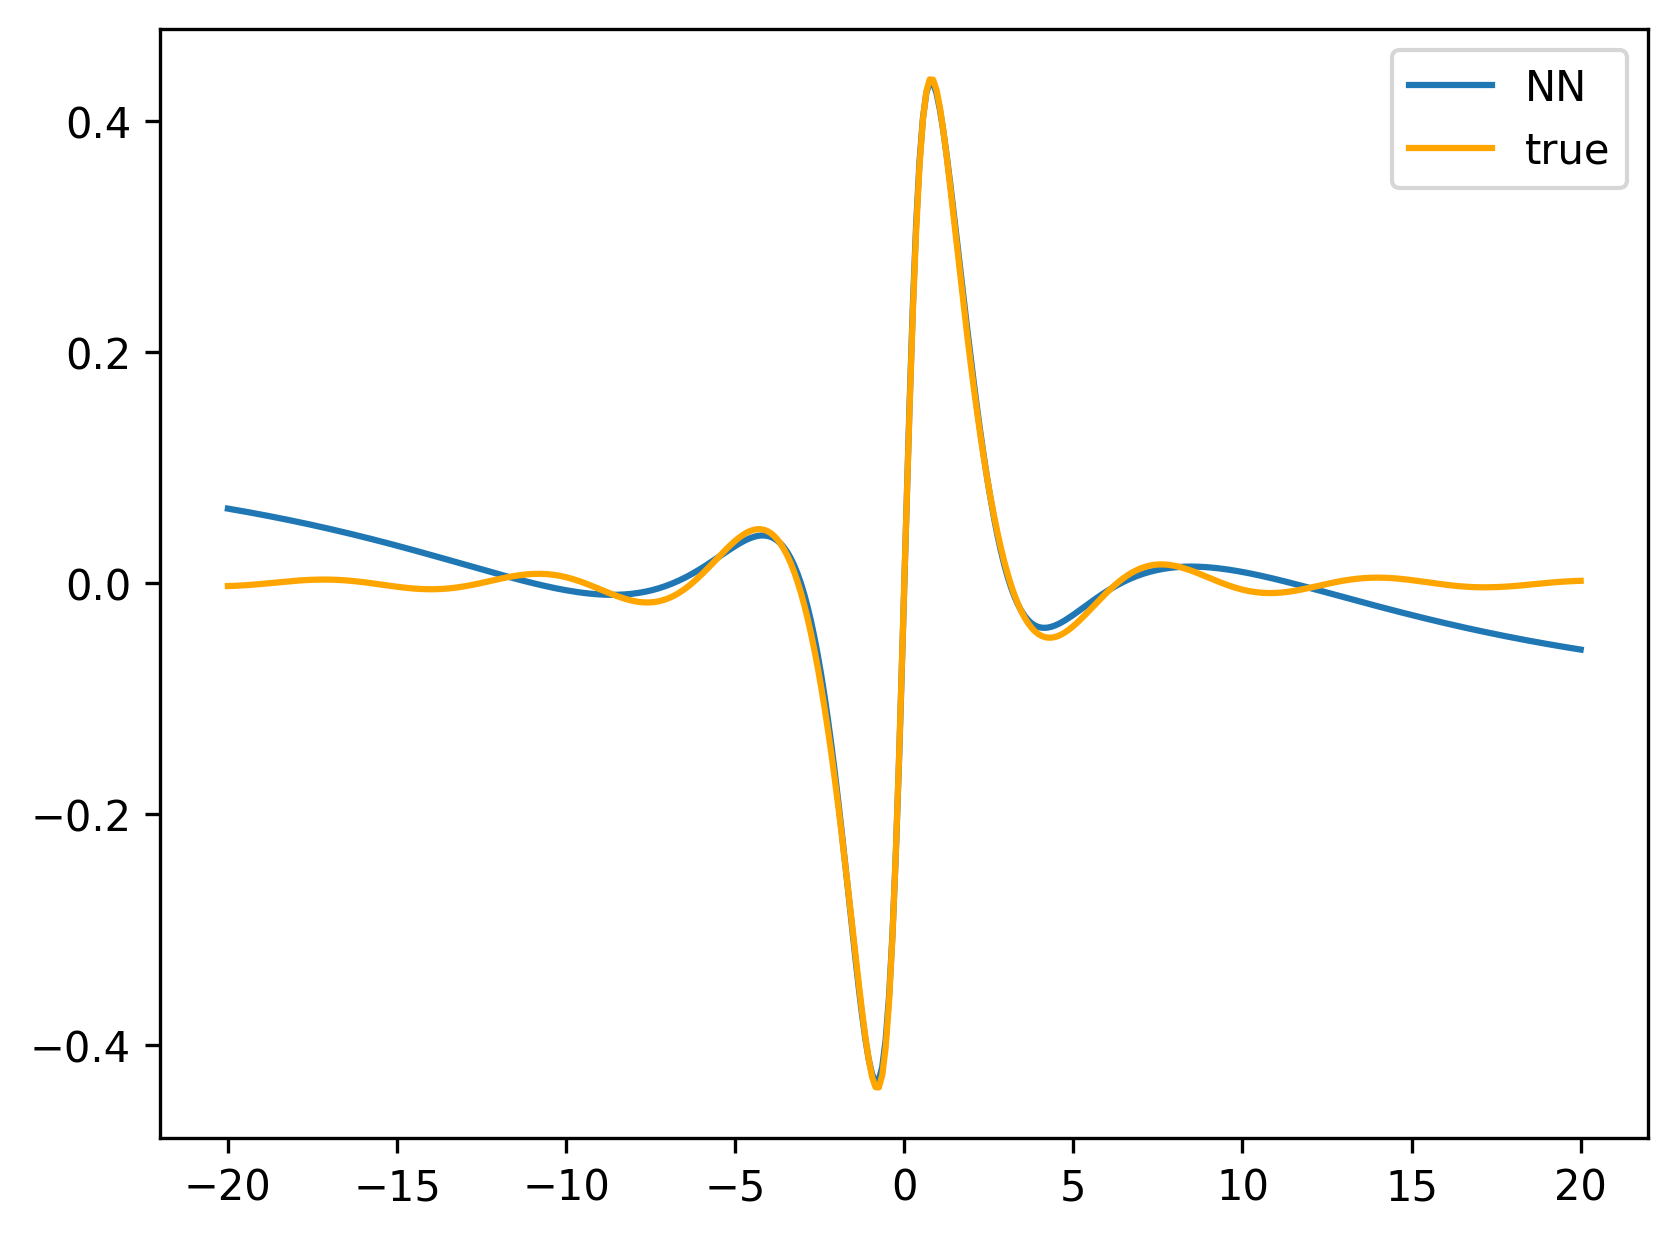

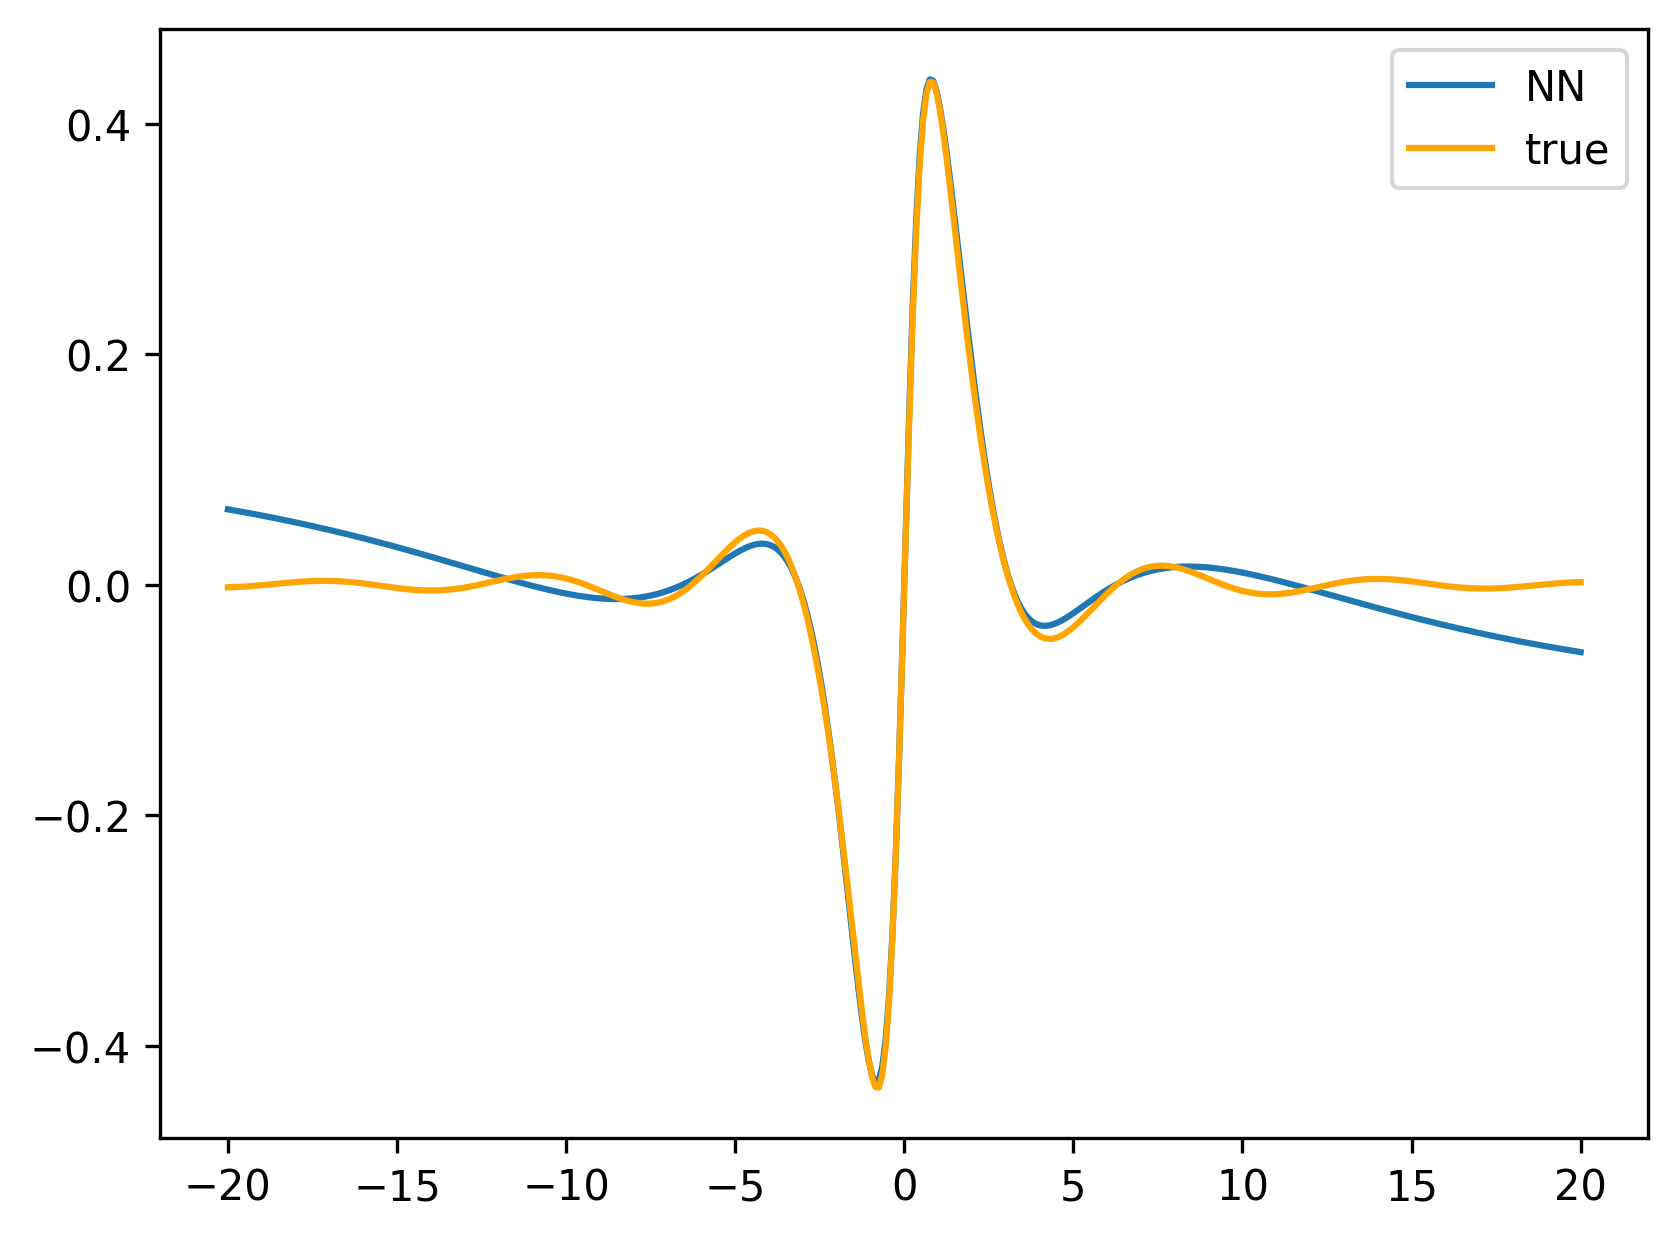

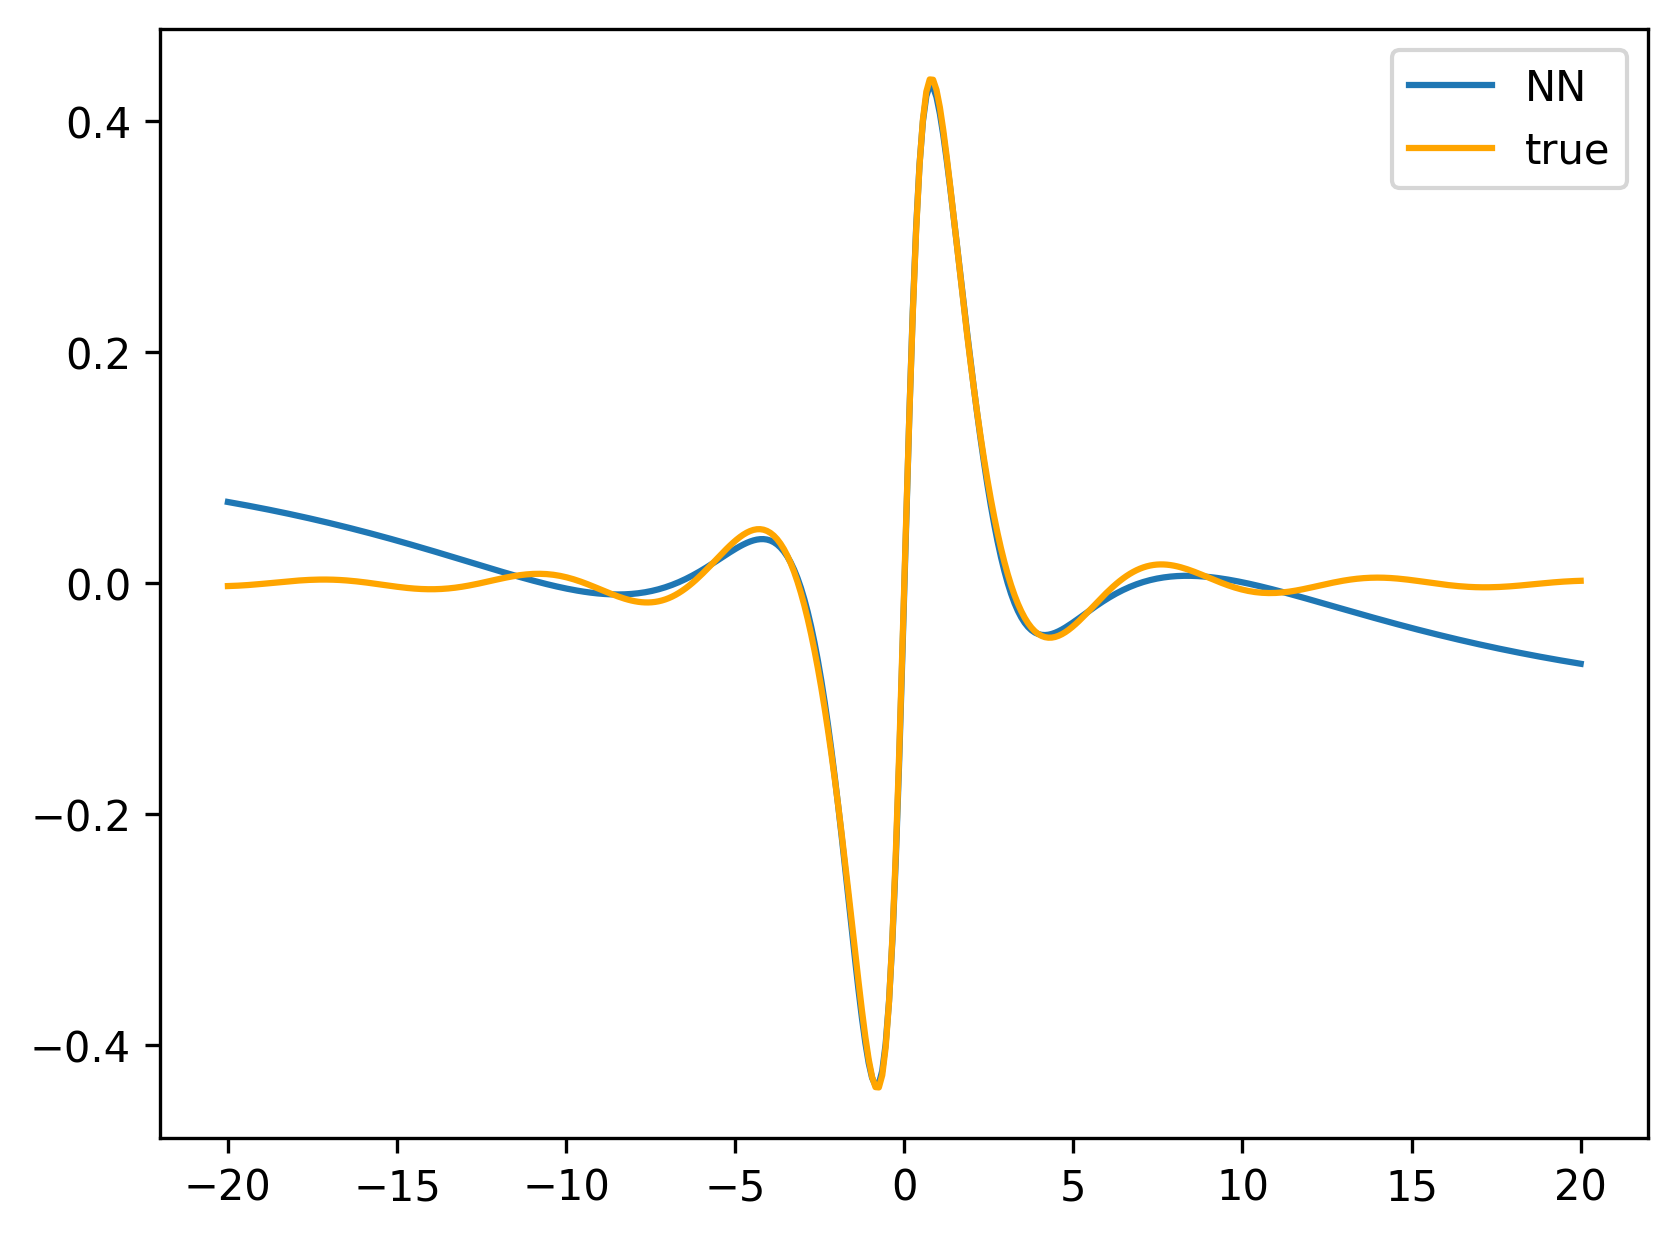

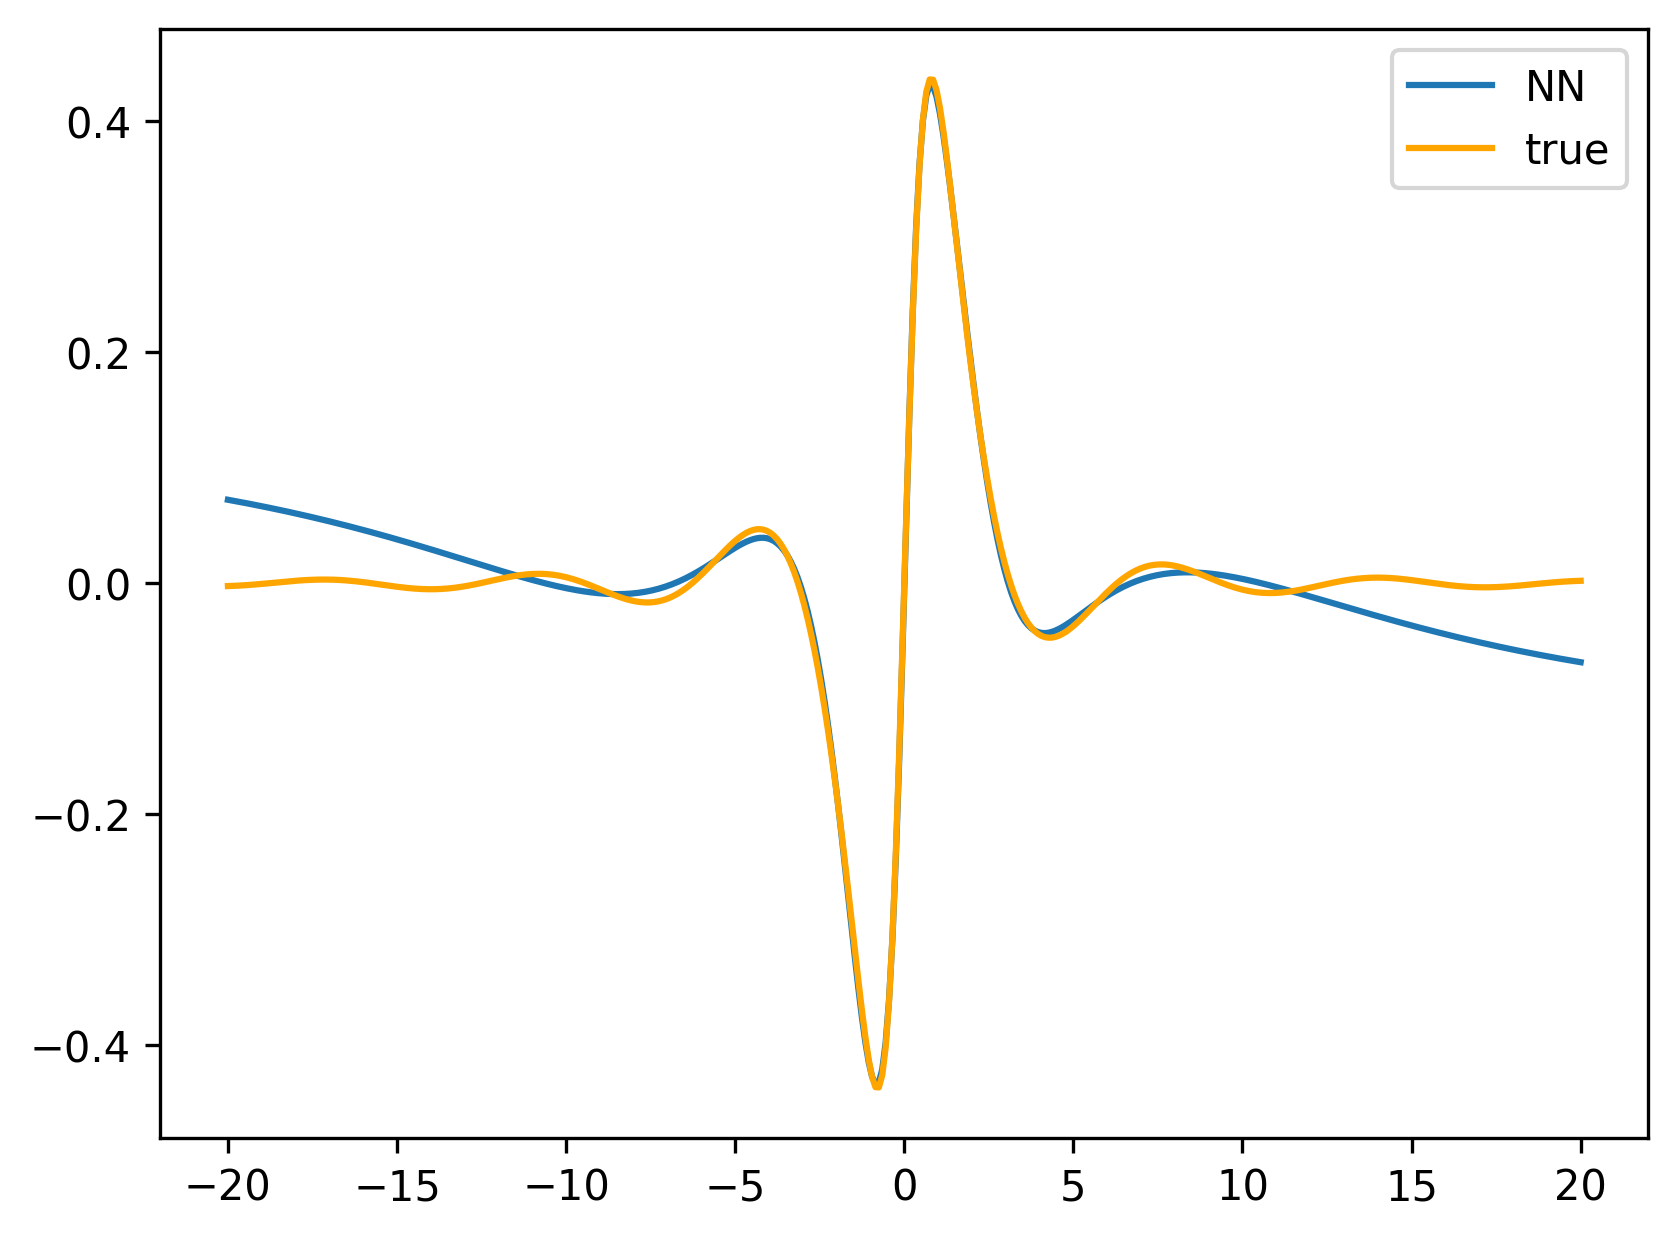

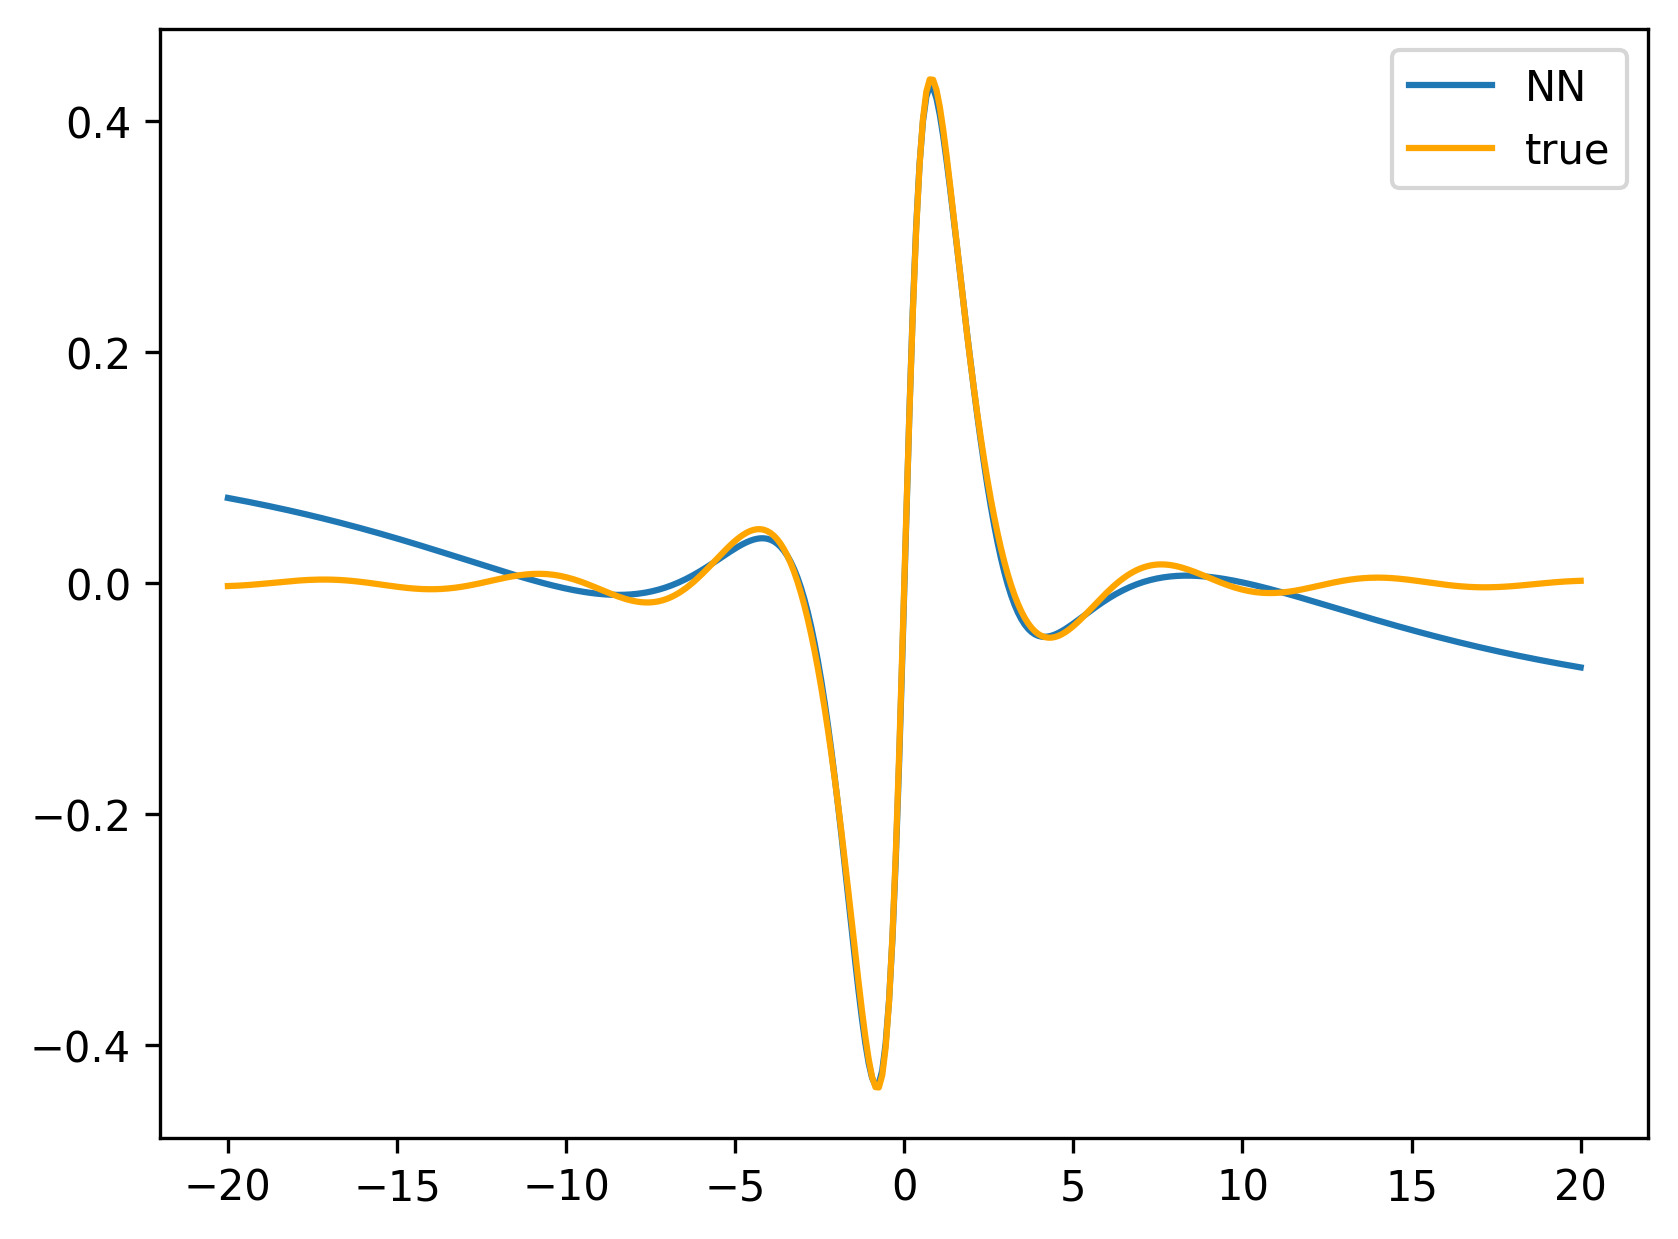

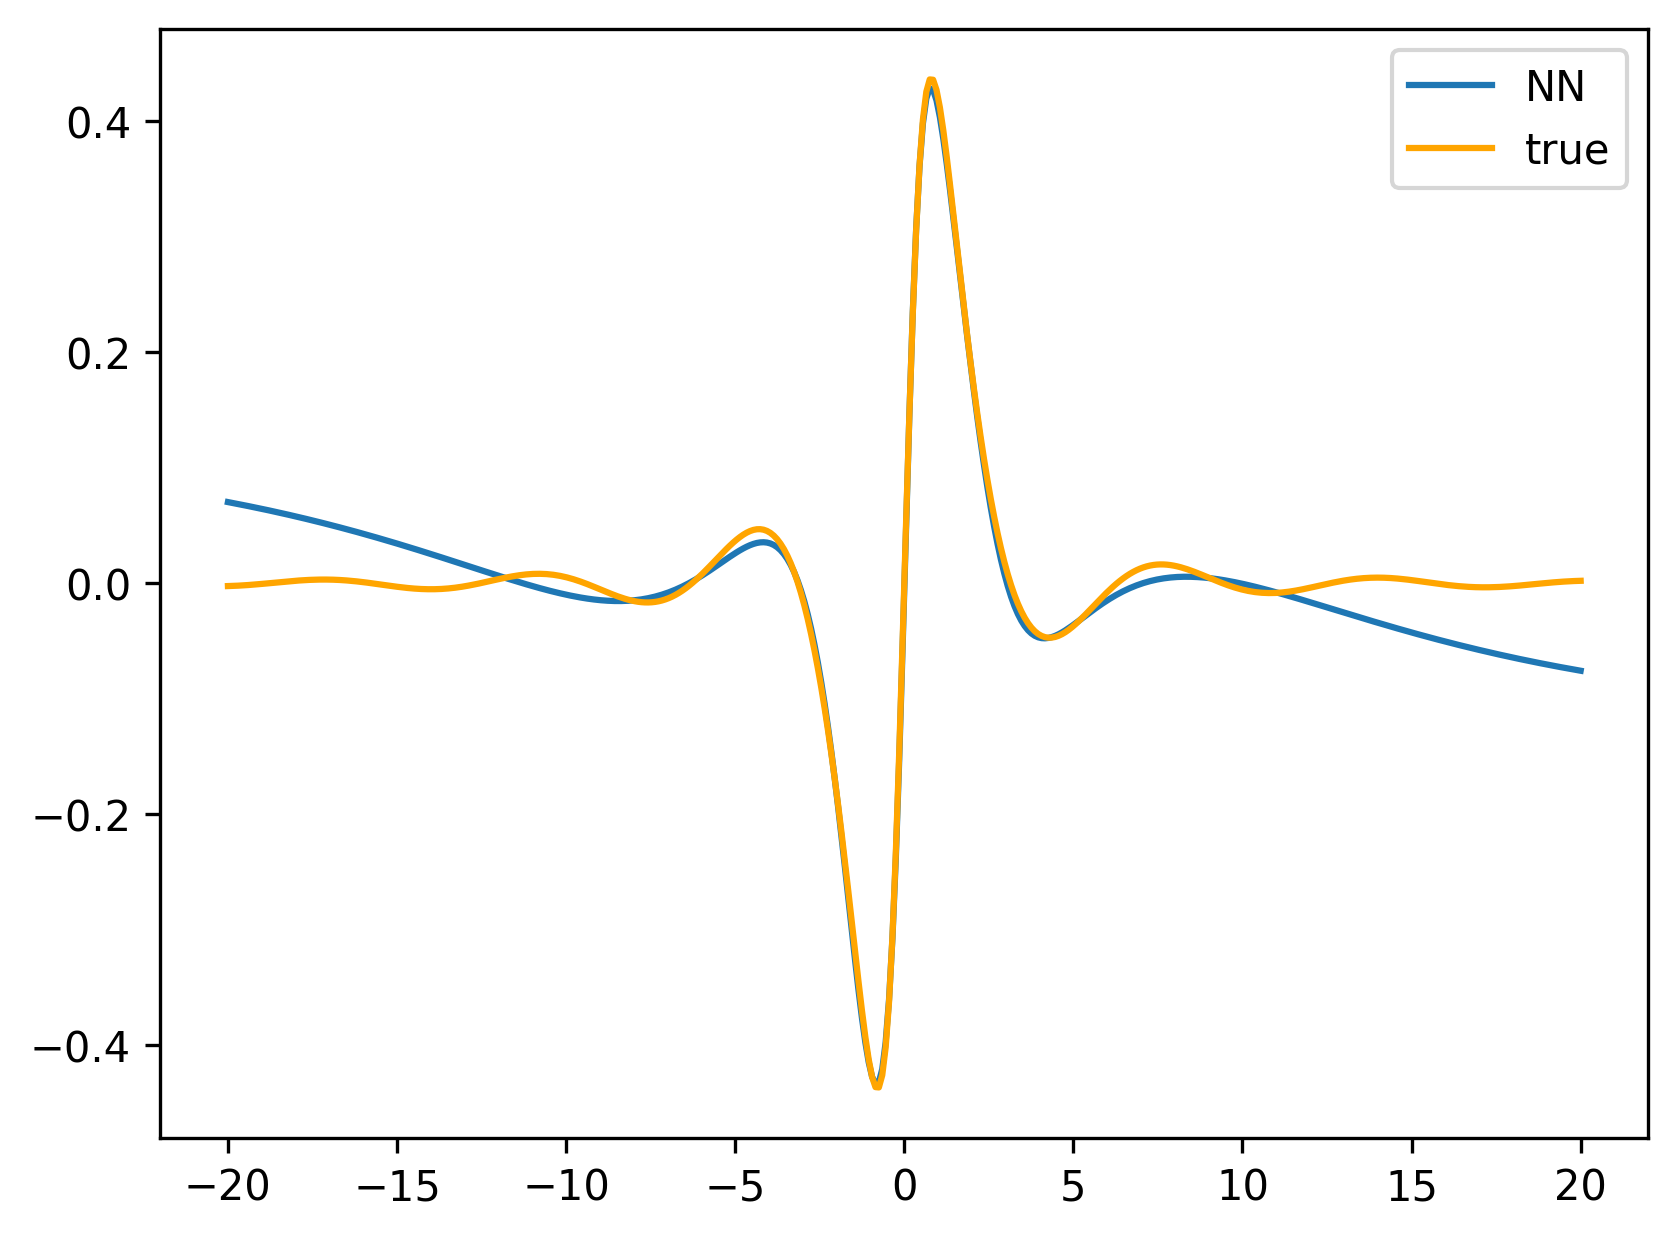

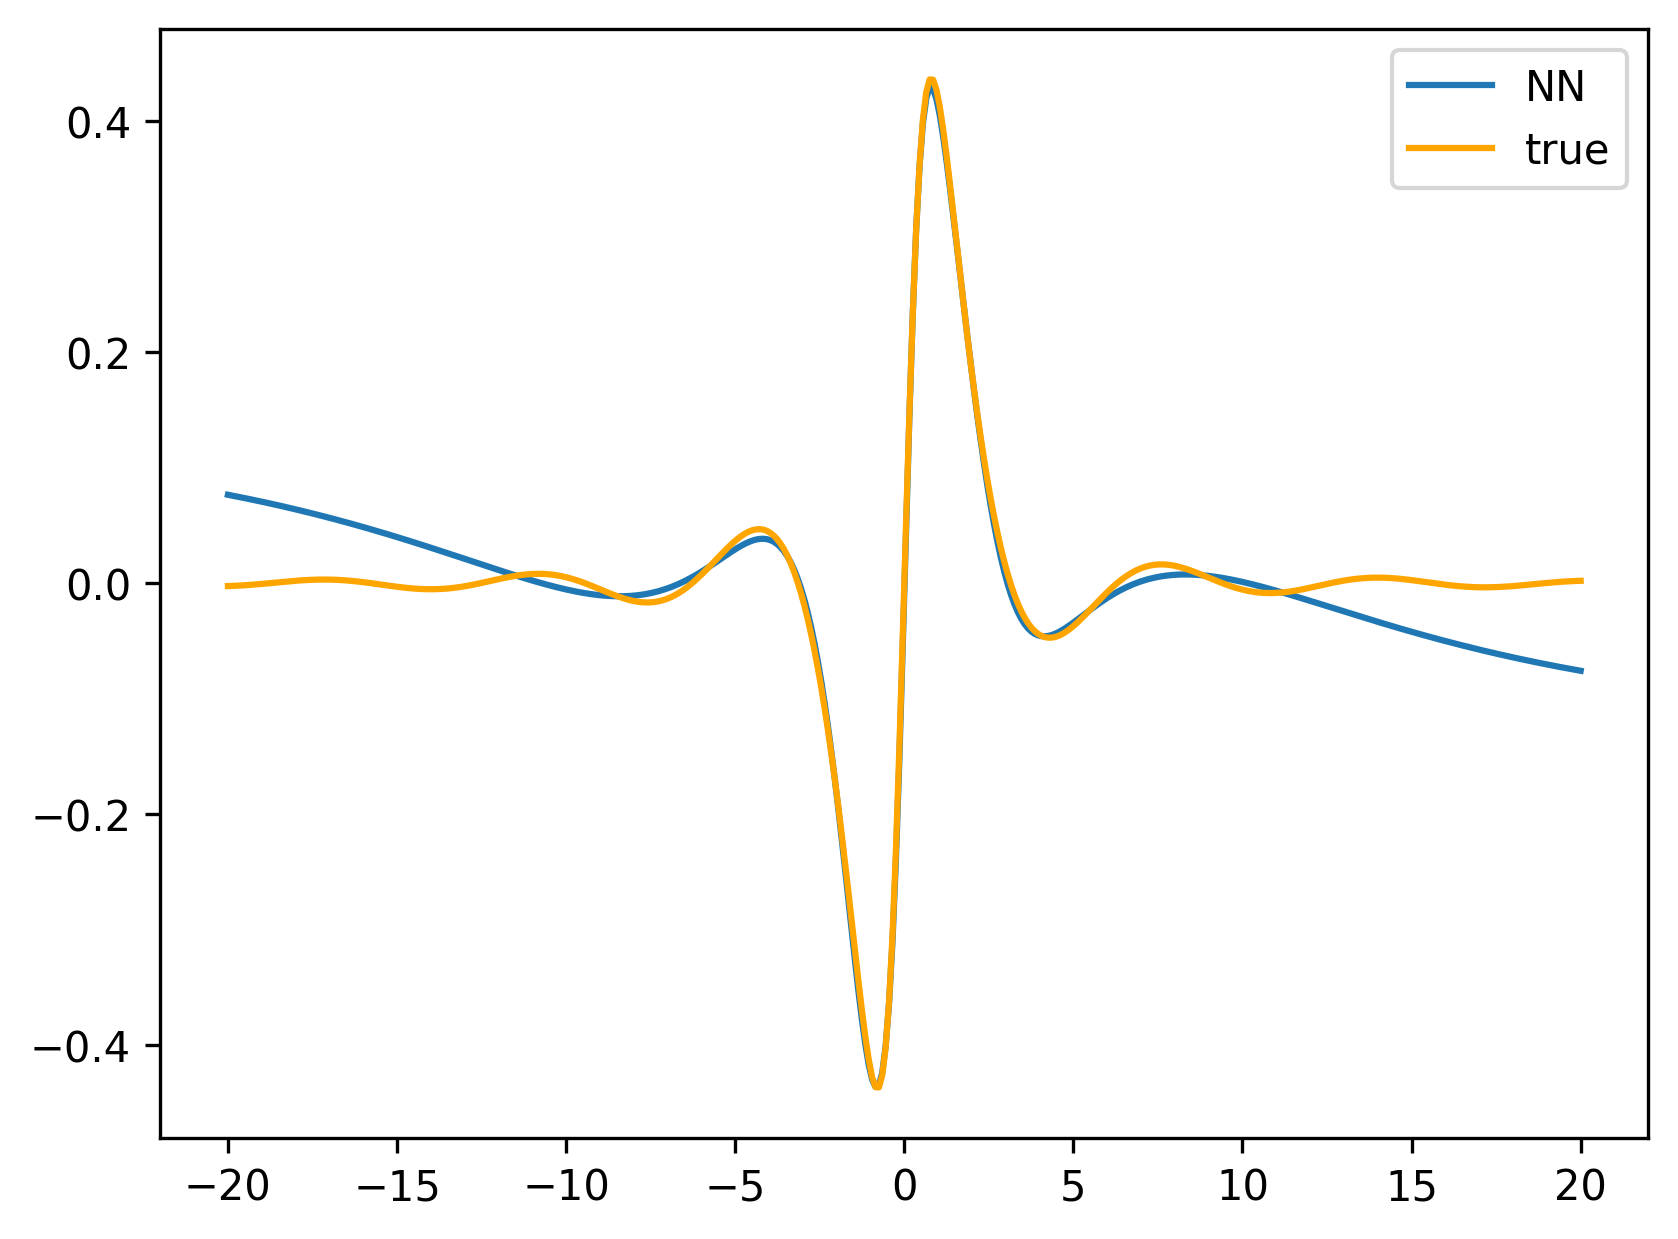

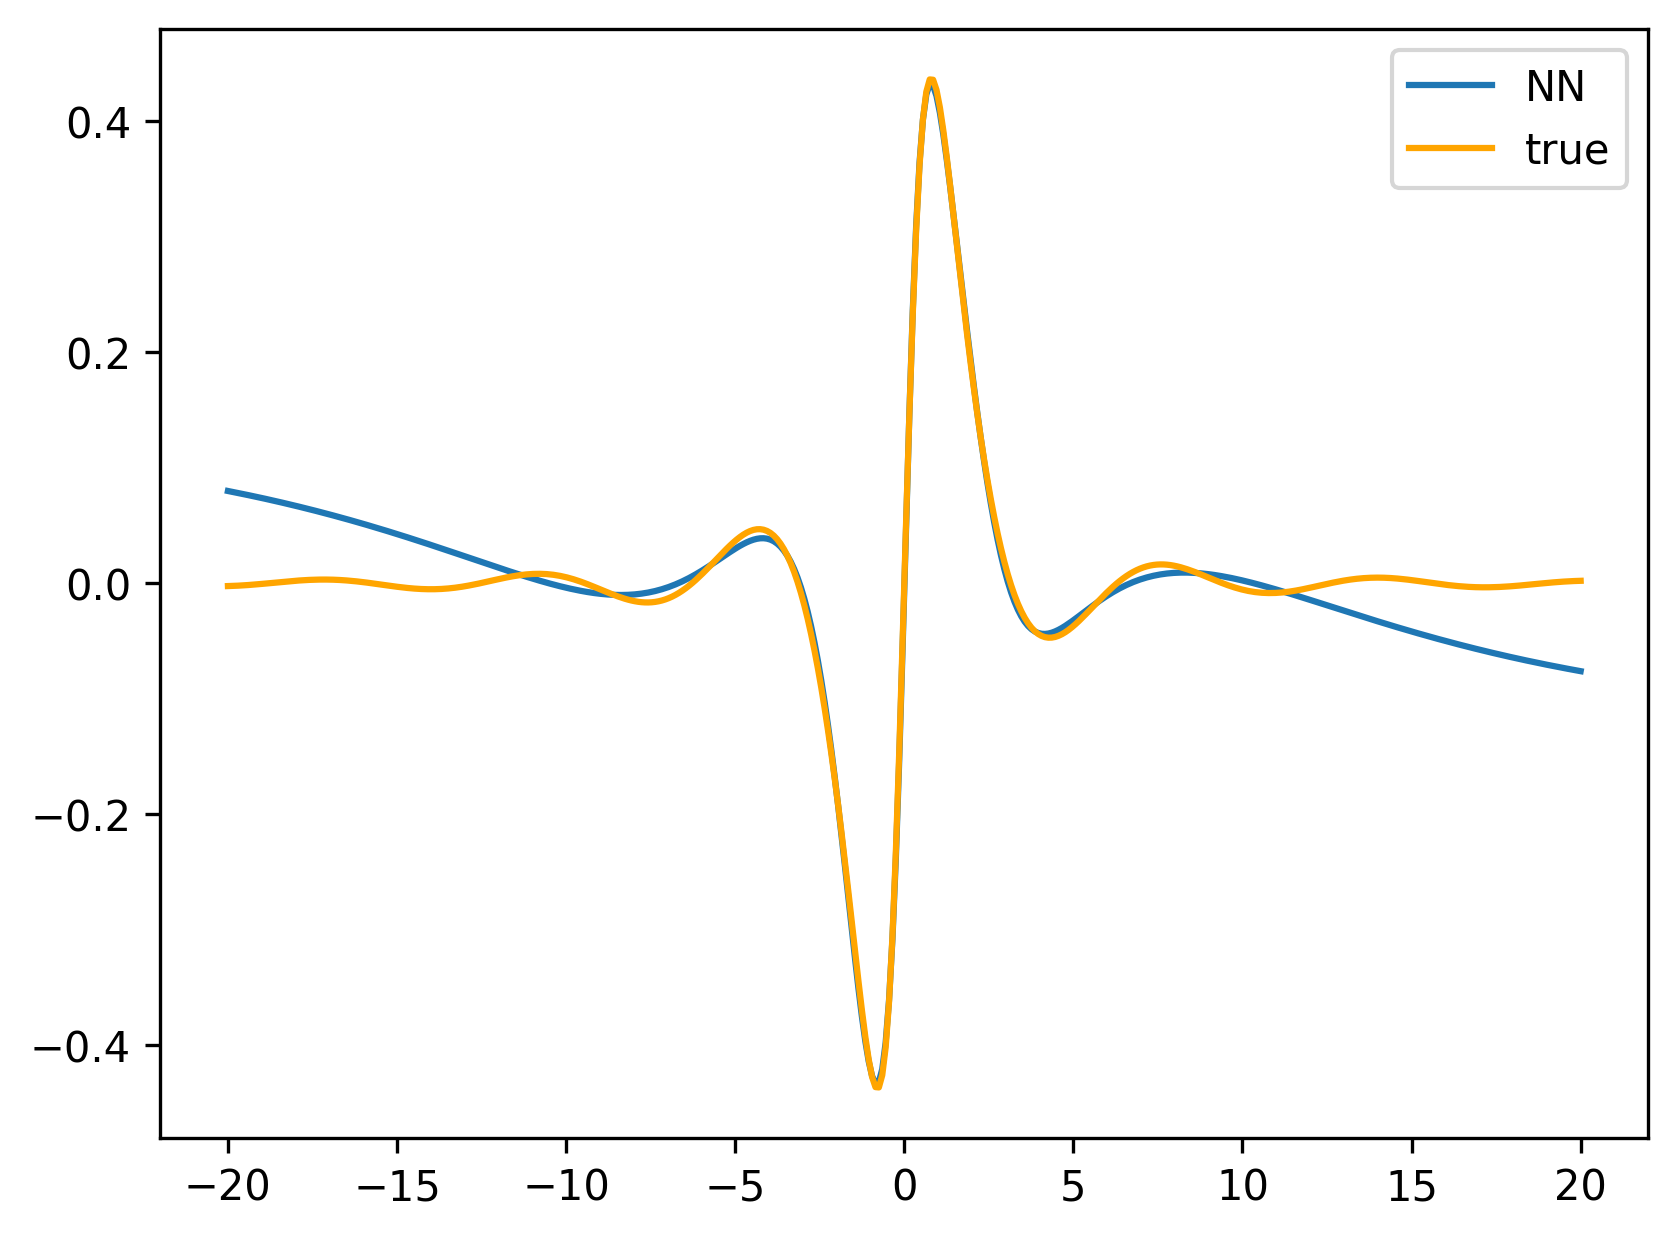

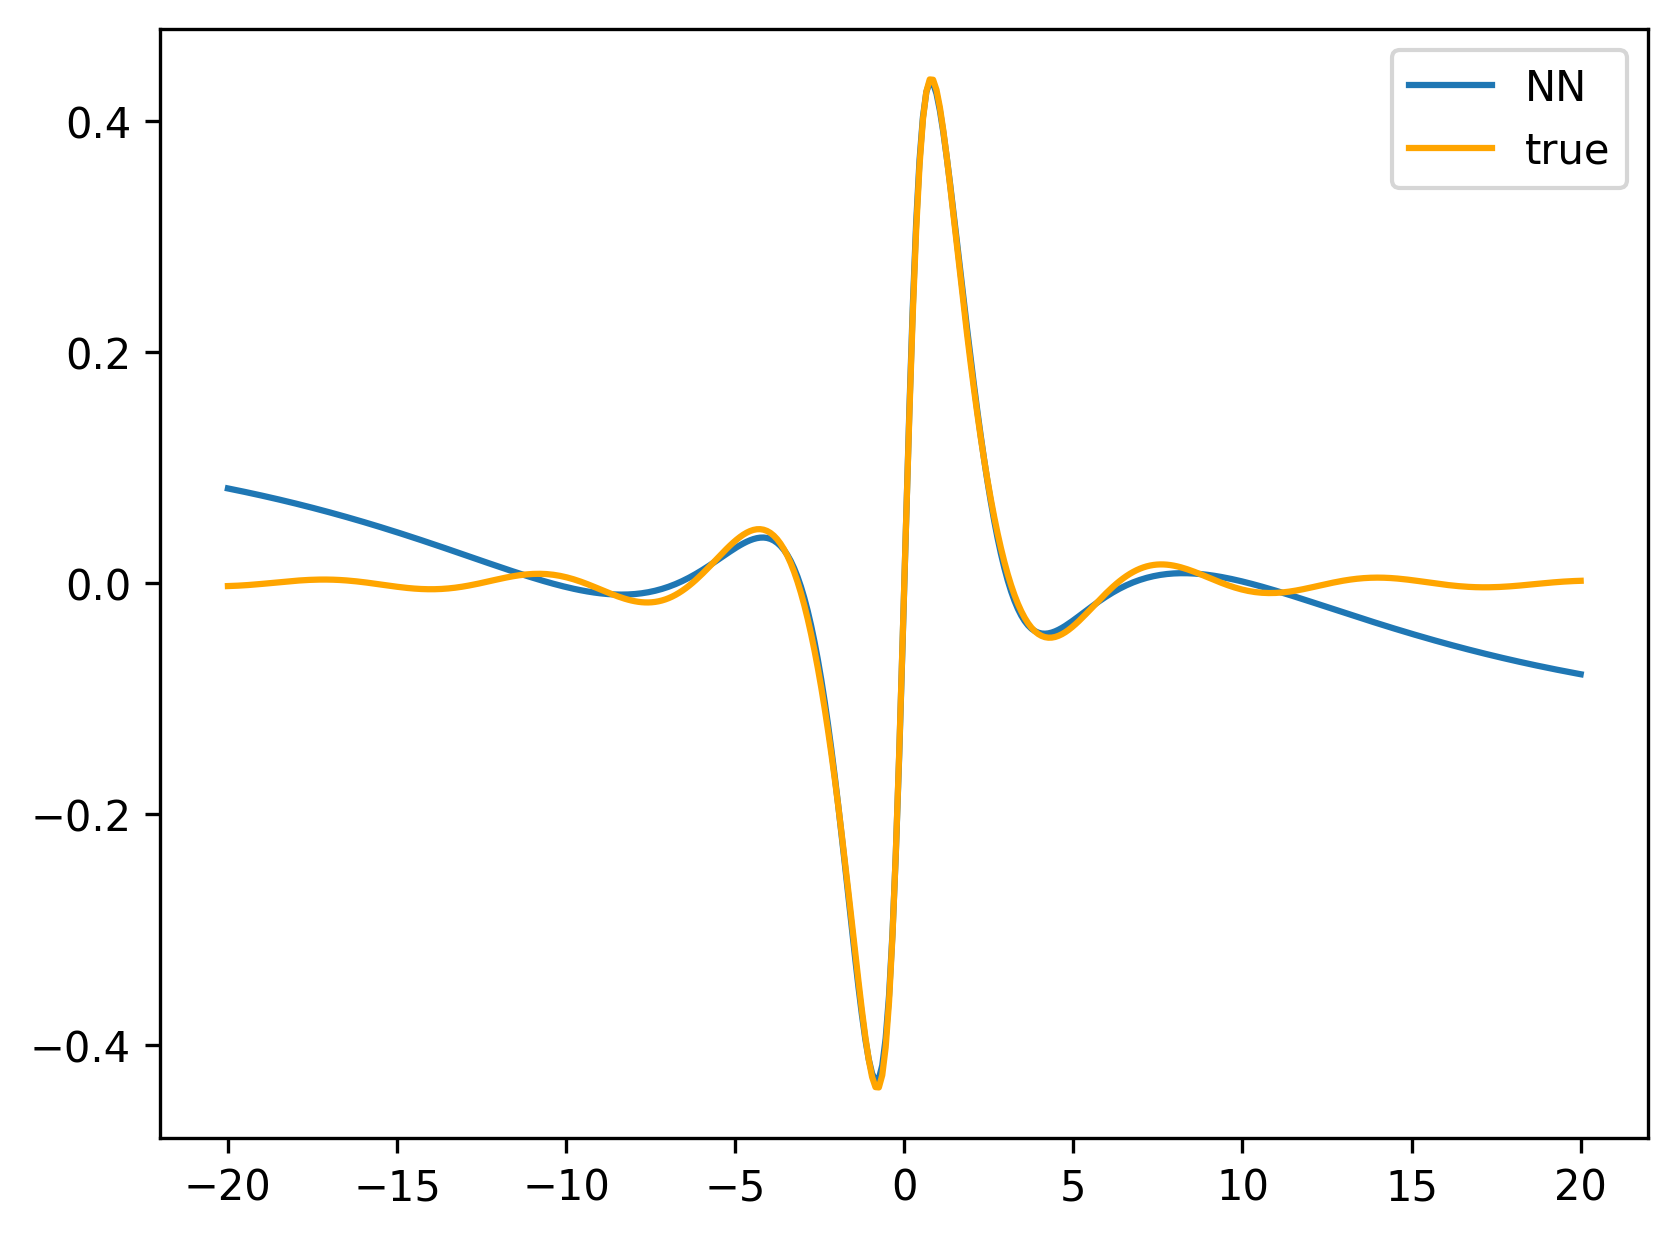

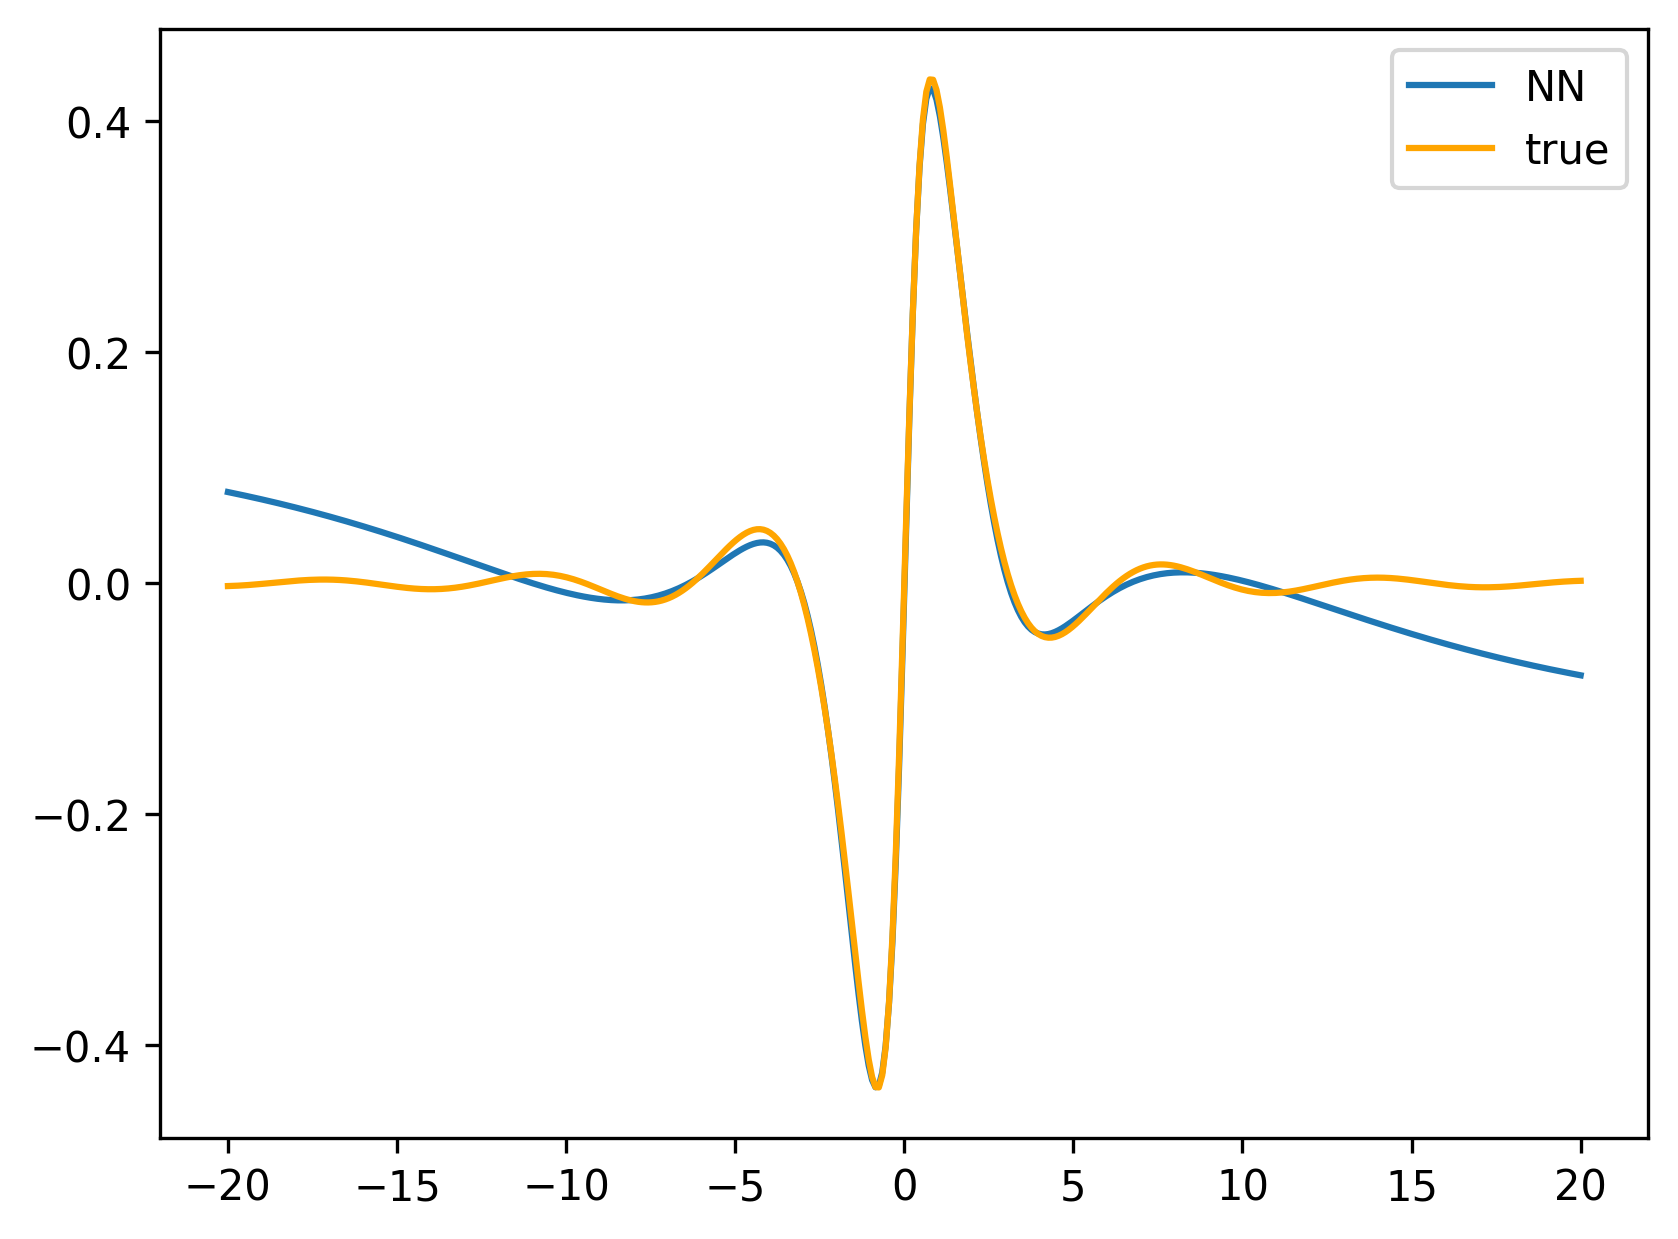

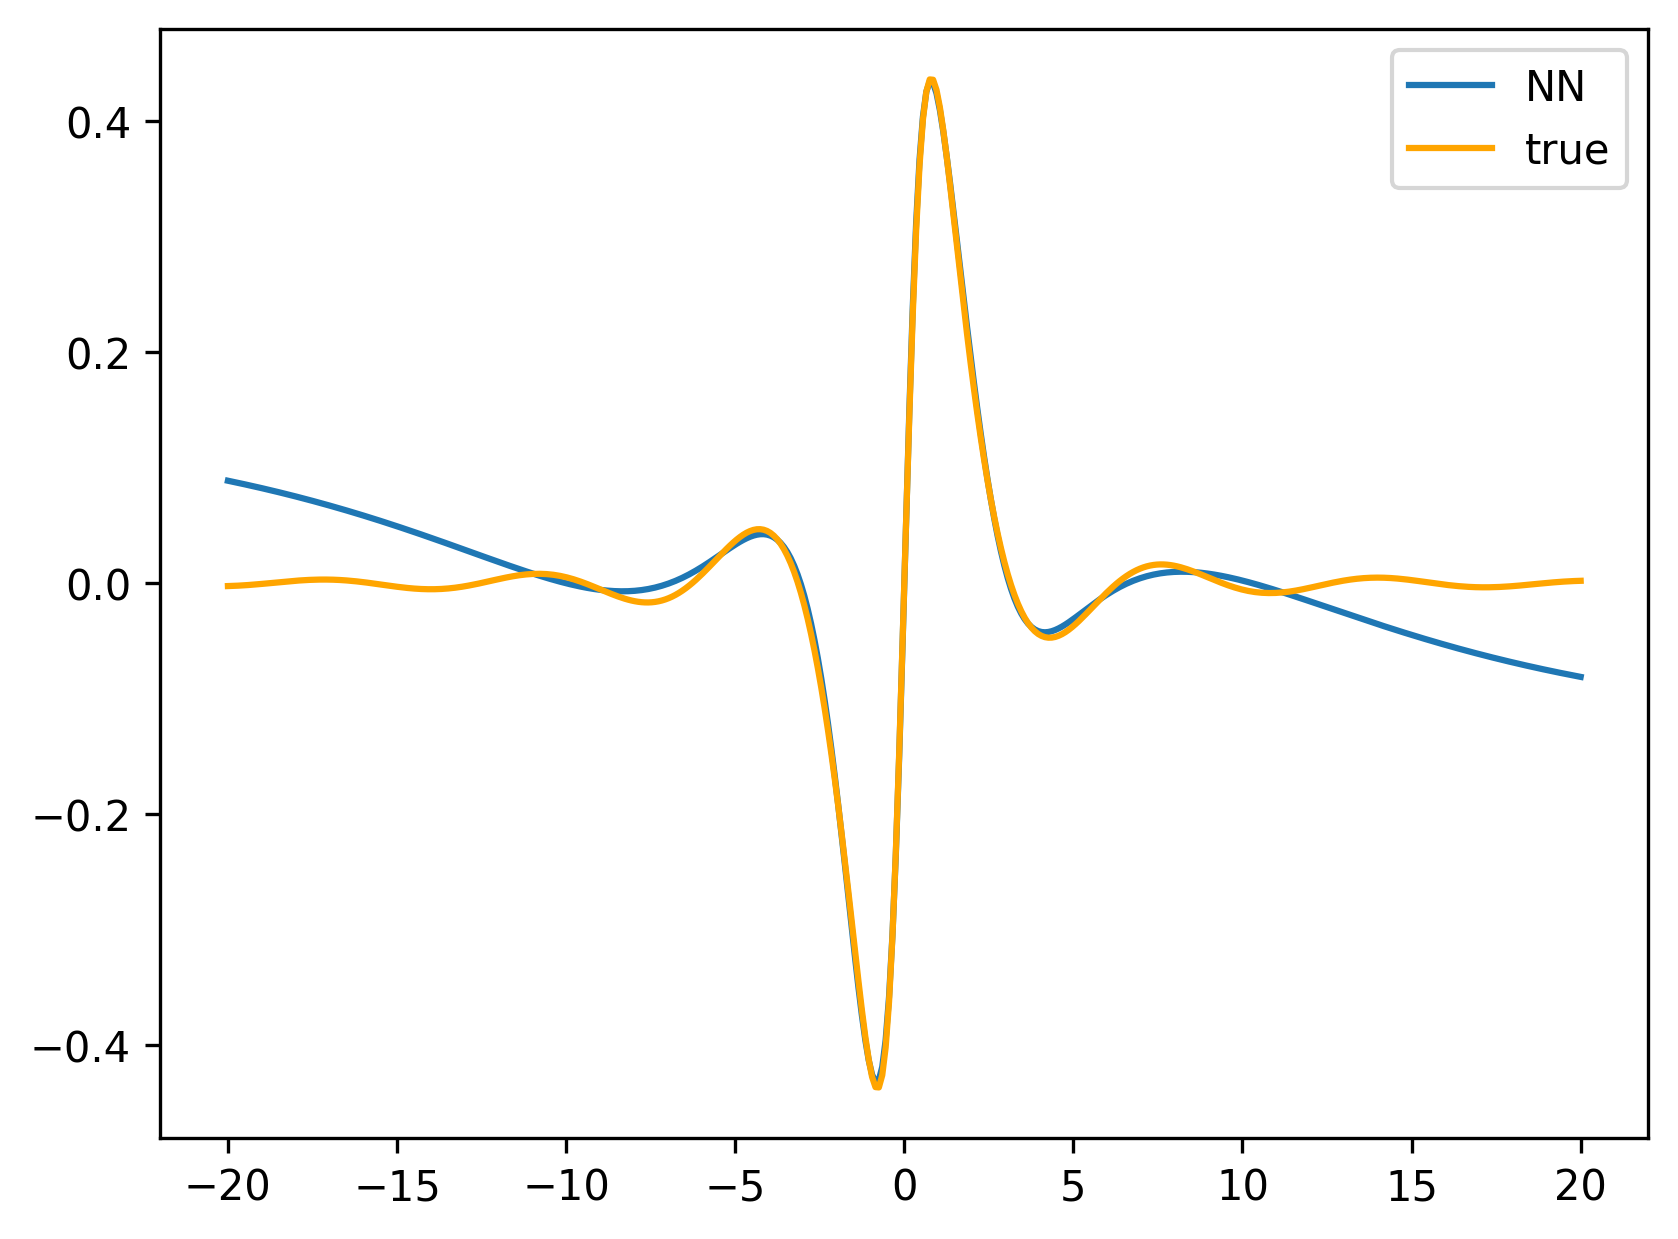

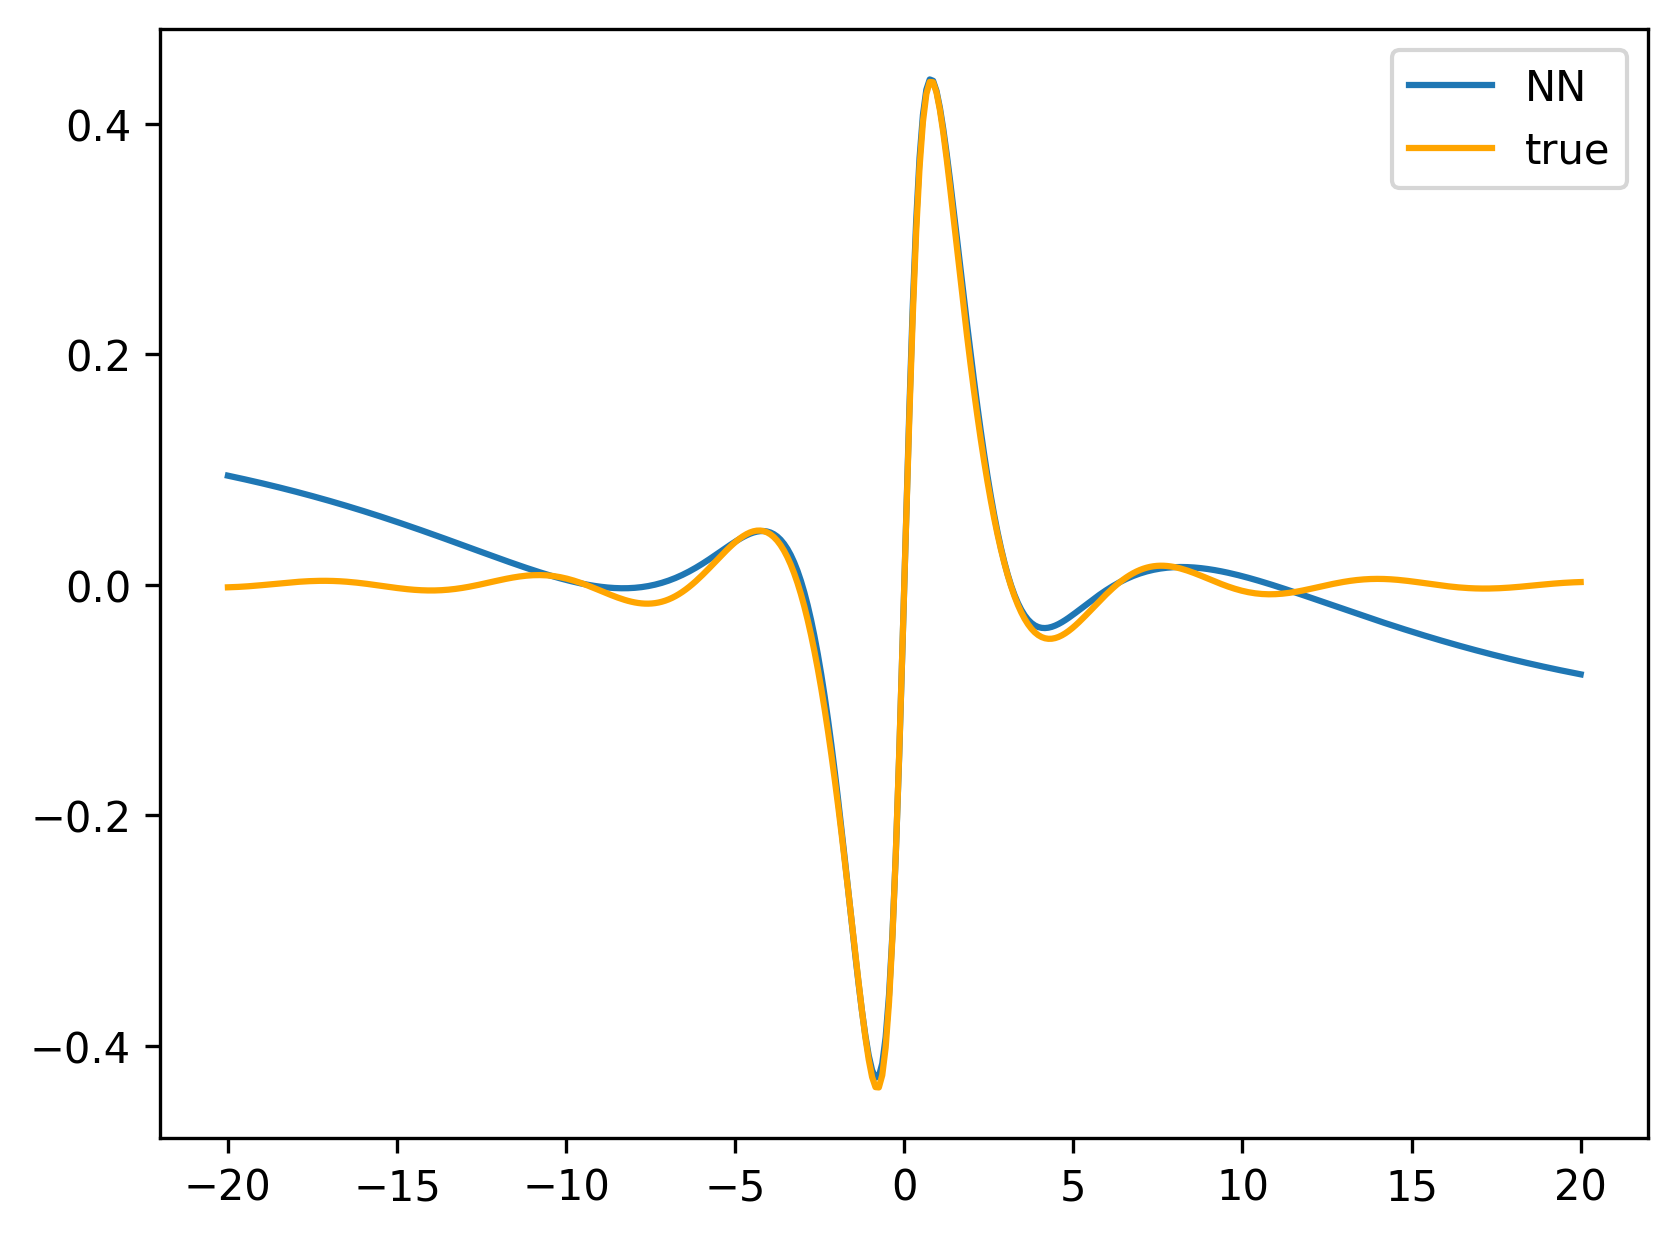

In [ ]:
# run this cell multiple times to train the network better and better!

# a simple 1D function:
def my_target(y):
    return( np.sin(y)/(1+y**2) ) # a wave packet...

# training on a simple 1D function:

training_batches=1000 # number of training batches
batchsize=20 # samples per batch
costs=np.zeros(training_batches) # array for storing costs

framenumber=30
for frame in range(framenumber):
  # run through all training batches:
  for j in range(training_batches):
    y_in=np.random.uniform(low=-10.0,high=+10.0,size=[batchsize,1]) # get randomly scattered points (uniform distribution)
    y_target=my_target(y_in) # produce correct outputs (our target)
    costs[j]=Net.train_on_batch(y_in,y_target) # train on this batch of samples
    print(str(costs[j]),end="   \r") # print current cost function, overwrite line always

  # get the output on a 1D grid of points:
  N=400 # number of points
  y_in=np.zeros([N,1]) # prepare correct shape for network, here N becomes the batch size
  y_in[:,0]=np.linspace(-20.0,20.0,N) # fill with interval
  y_out=Net.predict_on_batch(y_in) # apply the network to this set of points!

  plt.plot(y_in,y_out,label="NN")
  plt.plot(y_in,my_target(y_in),color="orange",label="true")
  plt.legend()
  if framenumber%5==0: #just plot every fifth frame
    plt.show()
    sleep(0.1)

